<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fpranathi_kolla/weeks/week_06/06_2D_Wings_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05: The 2D Wing — Connecting Shape to Amplitude

In the previous two weeks you built a statistical description of the *shape* of a solar butterfly wing: the mean emergence latitude drifts equatorward following a universal exponential, and the spread σ around that mean follows a piecewise-linear function of mean latitude μ. What the model is still missing is any connection to how *strong* a cycle is. A weak cycle and a strong cycle can share the same geometric skeleton — what distinguishes them is the overall level of activity.

This notebook completes the picture in two stages. **Sections 1–5** recap and finalize the shape model from Week 04, producing its key result: a universal equatorward line in σ(μ) space that is shared by every hemisphere-cycle, plus a per-cycle poleward slope that captures each cycle's individual character. **Tasks 17–20** ask you to bring in a new ingredient — total sunspot area — and find quantitative relationships between cycle amplitude and the three shape parameters, ultimately synthesizing a full 2D butterfly wing from a single input number.

**By the end of this notebook you should be able to:**
- Explain what the universal equatorward line in σ(μ) space represents physically.
- Compute the peak amplitude of each hemispheric solar cycle from the sunspot area record.
- Describe quantitative relationships between cycle amplitude and the wing shape parameters (μ₀, μ_peak, m_i).
- Generate a synthetic butterfly wing for a chosen cycle and compare it to real data.

In [1]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 1) Load data

We work with the same composite catalog of daily sunspot group measurements used in Weeks 03 and 04. Each row records one sunspot group observation: its date, heliographic latitude, and corrected area in millionths of a solar hemisphere (MSH). We add convenience columns for hemisphere, absolute latitude, and decimal year that all subsequent sections depend on.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar, minimize

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_peak_area.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()

df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"] = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

# Remove pores and small objects
df = df[df["correctedArea"] > 30].copy()


df.head()

/tmp/ipykernel_20587/2077808080.py:11: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_20587/2077808080.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,time,hemisphere,abs_latitude,year,decimal_year
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,SC_101,NaN,1.0,1825.843258,south,1.2,1825,1825.845996
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,SC_102,NaN,1.0,1825.851472,south,17.9,1825,1825.854209
4,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,SC_103,NaN,1.0,1825.856947,south,27.4,1825,1825.859685
7,1825-11-14,12.0,0.0,0.0,-12.4,324.5,630.0,180.0,SC_104,NaN,1.0,1825.867899,south,12.4,1825,1825.870637
9,1825-11-16,10.0,30.0,0.0,14.9,324.5,380.0,120.0,SC_105,NaN,1.0,1825.873374,north,14.9,1825,1825.876112


/tmp/ipykernel_20587/2945696721.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


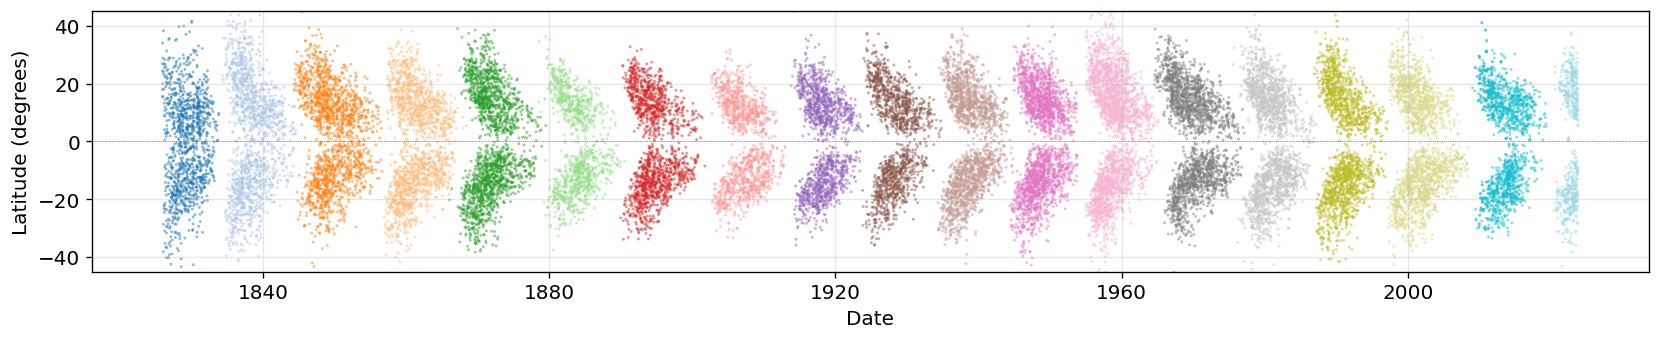

In [3]:
# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=3,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.5, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 2) Standardize time: align cycles at the 15° crossing (τ)

Solar cycles don't start on the same calendar date and don't last the same length of time, so we can't compare them on a shared time axis without first choosing a common reference point. The anchor we use is the moment when the **yearly mean absolute emergence latitude crosses 15° on its way equatorward** — a latitude that falls reliably in the well-observed middle of every cycle.

For each (cycle, hemisphere) pair we find that crossing by linear interpolation between the last year the mean sits above 15° and the first year it falls below. The shifted coordinate **τ = decimal\_year − t₀** is in physical units (years) and places all cycles on the same footing regardless of when they actually occurred.

In [5]:
t0_lookup = {}
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = yearly_mean.index.values, yearly_mean.values
    below = means < 15.0
    if not below.any() or below.all():
        continue
    idx1 = np.argmax(below)
    if idx1 == 0:
        continue
    y0, mu0 = years[idx1 - 1], means[idx1 - 1]
    y1, mu1 = years[idx1],     means[idx1]
    t0_lookup[(cyc, hemi)] = y0 + (15.0 - mu0) / (mu1 - mu0)

df["t0"]  = df.apply(lambda r: t0_lookup.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

## 3) Fit a universal mean path μ(τ) and refine the time origin

The equatorward drift of the mean emergence latitude follows an exponential decay:

$$\mu(\tau) = a \, e^{-\tau / b}$$

where **a** is the mean latitude at τ = 0 and **b** is the e-folding timescale — the number of years it takes the mean to drop by a factor of e ≈ 2.7. In Week 04 you found that the best-fit (a, b) is nearly the same for every cycle, so here we fit it once, globally, by pooling binned (τ, μ) measurements from all hemisphere-cycles.

With the universal (a, b) in hand we can refine each cycle's t₀: a small time shift Δt is found for each hemisphere-cycle that minimises its residuals against the common template. The refined coordinate **τ_refined** gives a tighter alignment than the raw 15° crossing, because it uses the full shape of the wing rather than a single crossing point.

In [6]:
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS_13   = 20
cycles_13   = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
cmap_13     = cm.get_cmap("tab20", len(cycles_13))
cyc_idx_13  = {c: i for i, c in enumerate(cycles_13)}

all_tau_bins, all_mu_bins = [], []
hemicycle_bins_13 = {}

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_13 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS_13):
            lats_bin = df_sel.loc[
                (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt = np.array(bt); bm = np.array(bm)
        hemicycle_bins_13[(cyc, hemi)] = (bt, bm)
        all_tau_bins.extend(bt); all_mu_bins.extend(bm)

popt_global, _ = curve_fit(exp_decay, all_tau_bins, all_mu_bins, p0=[15.0, 5.0])
a_mu_univ, b_mu_univ = popt_global
print(f"Universal μ(τ):  a = {a_mu_univ:.2f}°   b = {b_mu_univ:.2f} yr")

# Refine t₀ per hemisphere-cycle
t0_refined = {}
for (cyc, hemi), (bt, bm) in hemicycle_bins_13.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    res = minimize_scalar(_res, bounds=(-4, 4), method="bounded")
    t0_refined[(cyc, hemi)] = t0_lookup[(cyc, hemi)] + res.x

df["t0_refined"]  = df.apply(lambda r: t0_refined.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

/tmp/ipykernel_20587/1516041124.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_13     = cm.get_cmap("tab20", len(cycles_13))


Universal μ(τ):  a = 16.34°   b = 8.49 yr


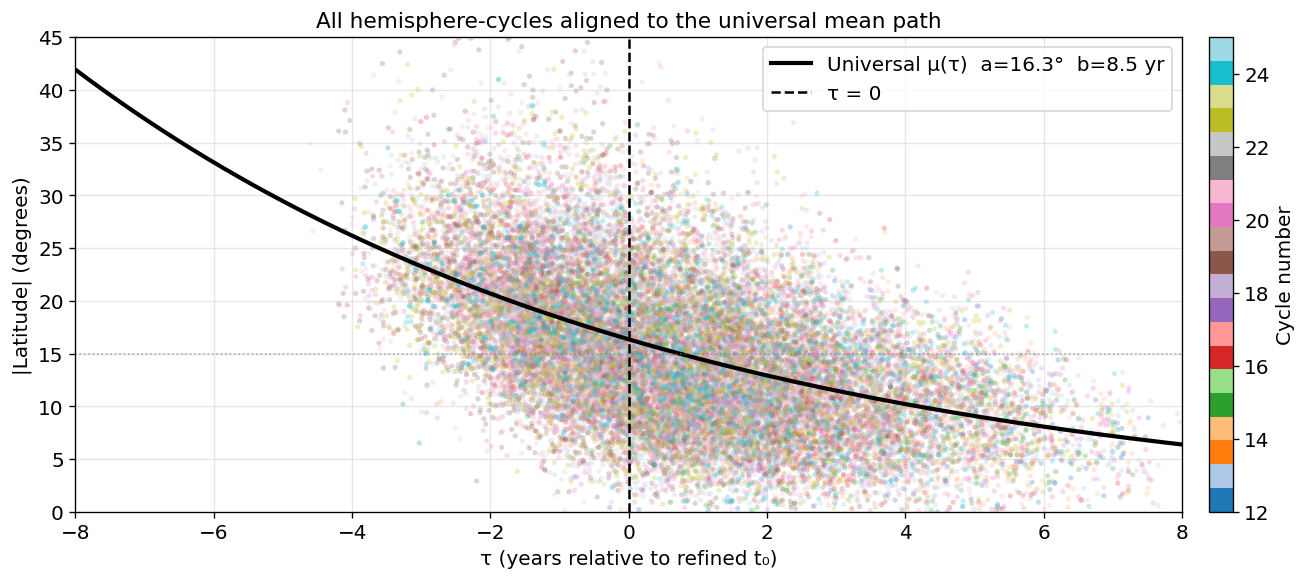

In [7]:
TAU_GRID_13 = np.linspace(-8, 8, 300)

# Plot 1: All hemisphere-cycles aligned to the universal mean path
fig1, ax1 = plt.subplots(figsize=(12, 5))
for (cyc, hemi) in hemicycle_bins_13:
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    grp  = df[mask]
    ax1.scatter(grp["tau_refined"], grp["abs_latitude"],
                s=10, color=cmap_13(cyc_idx_13[cyc]), alpha=0.25, edgecolors="none")
ax1.plot(TAU_GRID_13, exp_decay(TAU_GRID_13, a_mu_univ, b_mu_univ),
         color="black", linewidth=2.5,
         label=f"Universal μ(τ)  a={a_mu_univ:.1f}°  b={b_mu_univ:.1f} yr")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to refined t₀)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles aligned to the universal mean path")
ax1.set_ylim(0, 45); ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right")
sm1 = plt.cm.ScalarMappable(cmap="tab20",
                              norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm1.set_array([])
fig1.colorbar(sm1, ax=ax1, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()


## 4) Model σ(μ): spread as a function of mean latitude

Rather than tracking the spread σ as a function of time, we describe it as a function of the **current mean emergence latitude** μ. This is more natural physically: two cycles at the same latitude should have similar spreads regardless of their absolute timing, because the spread is determined by the state of the dynamo, not by the calendar.

The spread is not monotonic in μ. At high latitudes (early in the cycle) there are few sunspots so the spread appears narrow; at low latitudes (late in the cycle) the active zone has collapsed toward the equator and is narrow again. The maximum spread occurs somewhere in between, at a characteristic mid-cycle latitude μ_peak. This bell-shaped behaviour in μ-space is captured by a **split Gaussian**:

$$\sigma(\mu) = A \exp\!\left(-\frac{(\mu - \mu_{\mathrm{peak}})^2}{2 s_{L,R}^2}\right)$$

where $s_L$ governs the poleward side (large μ, early cycle) and $s_R$ governs the equatorward side (small μ, late cycle). When $s_L \neq s_R$ the envelope is asymmetric — which is what the data show.

In [8]:
def split_normal_mu(mu, A, mu_peak, s_L, s_R):
    return np.where(
        mu >= mu_peak,
        A * np.exp(-0.5 * ((mu - mu_peak) / s_L) ** 2),
        A * np.exp(-0.5 * ((mu - mu_peak) / s_R) ** 2),
    )

N_BINS_15 = 20
MU_GRID   = np.linspace(2, 42, 300)
results_15 = []

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bm_list, bs_list = [], []
        for i in range(N_BINS_15):
            lats_bin = df_sel.loc[
                (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bm_list.append(mu_f); bs_list.append(sigma_f)
        if len(bm_list) < 5:
            continue
        bm_arr = np.array(bm_list); bs_arr = np.array(bs_list)
        sidx = np.argsort(bm_arr)
        bm_arr, bs_arr = bm_arr[sidx], bs_arr[sidx]
        try:
            p0 = [bs_arr.max(), bm_arr[np.argmax(bs_arr)], 5.0, 4.0]
            popt, _ = curve_fit(split_normal_mu, bm_arr, bs_arr, p0=p0, maxfev=10_000)
            A_f, mu_peak_f, sL_f, sR_f = popt
        except RuntimeError:
            continue
        if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            continue
        results_15.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_f, mu_peak=mu_peak_f, sL=sL_f, sR=sR_f,
            sigma_curve=split_normal_mu(MU_GRID, A_f, mu_peak_f, sL_f, sR_f),
            bin_mu=bm_arr, bin_sigma=bs_arr,
        ))

print(f"Fitted {len(results_15)} hemisphere-cycles.")

Fitted 15 hemisphere-cycles.


## 5) Universal piecewise-linear envelope

The key insight from Week 04 is that the equatorward half of every σ(μ) curve — the side where spots are migrating toward the equator — falls on **the same straight line** regardless of which cycle you look at. This universality tells us something deep: the process that narrows the active zone as the cycle approaches minimum is the same in every cycle. One slope and one intercept describe it for all of them.

The poleward half, by contrast, is cycle-specific: stronger cycles detach from the shared line at a higher latitude and descend more steeply. We encode this with a piecewise-linear model fitted *jointly* across all hemisphere-cycles:

$$\sigma(\mu) = \begin{cases} m_{\text{shared}}\,\mu + b_{\text{shared}} & \mu \le \mu_{\text{peak},i} \quad \text{(universal — same for all cycles)} \\ m_i\,\mu + b_i & \mu > \mu_{\text{peak},i} \quad \text{(per-cycle)} \end{cases}$$

Continuity at the detachment latitude $\mu_{\text{peak},i}$ determines $b_i$ automatically, so the model needs only two universal numbers $(m_{\text{shared}},\, b_{\text{shared}})$ and two per-cycle numbers $(\mu_{\text{peak},i},\, m_i)$ to fully describe each wing's spread profile. In the exercises below you will connect those per-cycle numbers to the overall strength of each cycle.

Universal line:  σ(μ) = 0.4429·μ + -0.1495
Zero crossing at μ = 0.34°
RMSE — split-normal independent : 0.845°
RMSE — piecewise-linear joint   : 0.886°  (+4.9%)


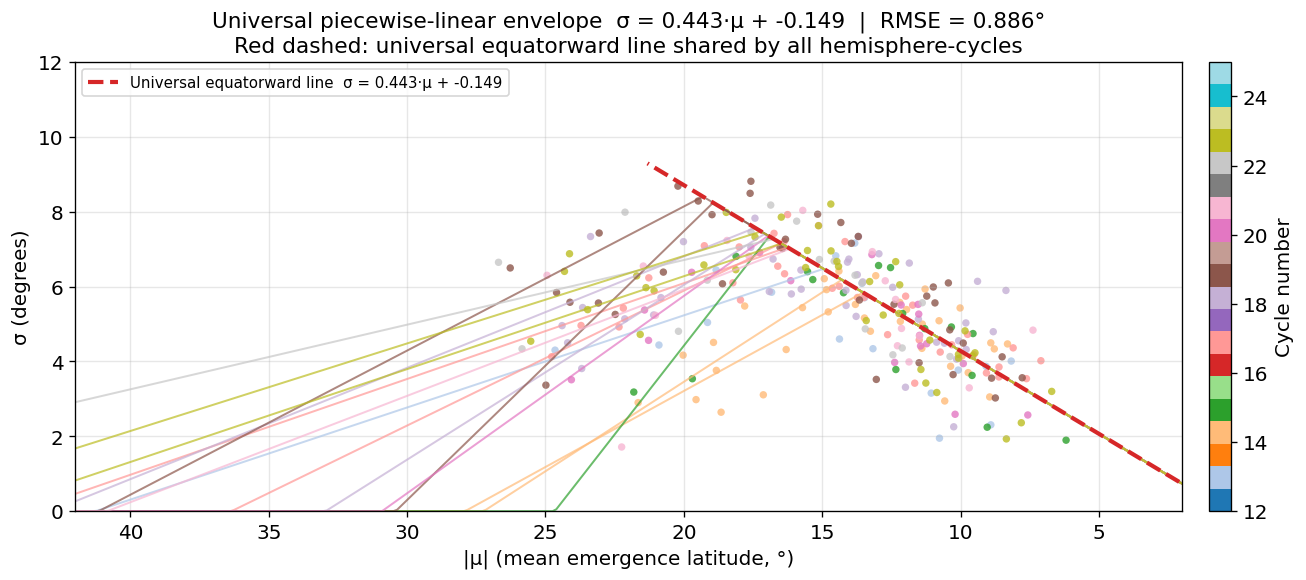


Per-cycle variability:
  μ_peak : 16.58° ± 1.46°  ← detachment latitude
  σ_peak : 7.19° ± 0.65°  ← derived amplitude
  m_i  : -0.4018 ± 0.2001  ← per-cycle poleward slope


In [9]:
def piecewise_linear_wing(mu, m_shared, b_shared, mu_peak, m_i):
    """Universal equatorward line + per-cycle poleward line, joined continuously at mu_peak."""
    sigma_peak = m_shared * mu_peak + b_shared
    b_per = sigma_peak - m_i * mu_peak
    return np.clip(
        np.where(mu <= mu_peak, m_shared * mu + b_shared, m_i * mu + b_per),
        0.0, None
    )

# Bootstrap: fit the shared equatorward line from pooled equatorward-side points
eq_mu, eq_sigma = [], []
for r in results_15:
    mask = r["bin_mu"] <= r["mu_peak"]
    eq_mu.extend(r["bin_mu"][mask]); eq_sigma.extend(r["bin_sigma"][mask])
m_init, b_init = np.polyfit(eq_mu, eq_sigma, 1)
m_i_init = np.mean([-r["A"] / (2 * max(r["sL"], 1.0)) for r in results_15])

# Joint L-BFGS-B optimisation
n_hc = len(results_15)

def residuals_pl(x):
    m_sh, b_sh = x[0], x[1]
    return sum(
        np.sum((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], m_sh, b_sh, x[2 + 2*i], x[3 + 2*i])) ** 2)
        for i, r in enumerate(results_15)
    )

x0 = np.array([m_init, b_init] + [val for r in results_15
                                   for val in (r["mu_peak"], m_i_init)])
bounds = list(zip(
    [0.0, -5.0] + [2.0, -5.0] * n_hc,
    [2.0,  5.0] + [38.0, 0.0] * n_hc,
))
opt = minimize(residuals_pl, x0, method="L-BFGS-B", bounds=bounds)

m_shared_fit, b_shared_fit = opt.x[0], opt.x[1]
print(f"Universal line:  σ(μ) = {m_shared_fit:.4f}·μ + {b_shared_fit:.4f}")
print(f"Zero crossing at μ = {-b_shared_fit / m_shared_fit:.2f}°")

# Reconstruct per-cycle fitted curves
MU_GRID_PL = np.linspace(2, 42, 300)
results_pl = []
for i, r in enumerate(results_15):
    mu_peak_i    = opt.x[2 + 2*i]
    m_i          = opt.x[3 + 2*i]
    sigma_peak_i = m_shared_fit * mu_peak_i + b_shared_fit
    results_pl.append(dict(
        cycle=r["cycle"], hemisphere=r["hemisphere"],
        m_shared=m_shared_fit, b_shared=b_shared_fit,
        mu_peak=mu_peak_i, m_i=m_i, sigma_peak=sigma_peak_i,
        sigma_curve=piecewise_linear_wing(
            MU_GRID_PL, m_shared_fit, b_shared_fit, mu_peak_i, m_i),
        bin_mu=r["bin_mu"], bin_sigma=r["bin_sigma"],
    ))

# RMSE comparison
def rmse_sn(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - split_normal_mu(
            r["bin_mu"], r["A"], r["mu_peak"], r["sL"], r["sR"])) ** 2)
        for r in res_list
    ]))

def rmse_pl(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], r["m_shared"], r["b_shared"], r["mu_peak"], r["m_i"])) ** 2)
        for r in res_list
    ]))

rmse_15 = rmse_sn(results_15)
rmse_16 = rmse_pl(results_pl)
print(f"RMSE — split-normal independent : {rmse_15:.3f}°")
print(f"RMSE — piecewise-linear joint   : {rmse_16:.3f}°  ({(rmse_16 - rmse_15)/rmse_15*100:+.1f}%)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for r in results_pl:
    c = cmap_13(cyc_idx_13.get(r["cycle"], 0))
    ax.scatter(r["bin_mu"], r["bin_sigma"], s=20, color=c,
               alpha=0.8, edgecolors="none", zorder=1)
    ax.plot(MU_GRID_PL, r["sigma_curve"], color=c,
            linewidth=1.2, alpha=0.7, zorder=2)

mu_eq = np.linspace(0, max(r["mu_peak"] for r in results_pl) + 2, 200)
ax.plot(mu_eq, np.clip(m_shared_fit * mu_eq + b_shared_fit, 0, None),
        color="tab:red", linewidth=2.5, linestyle="--",
        label=f"Universal equatorward line  σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}",
        zorder=5)

ax.invert_xaxis()
ax.set_xlim(42, 2)
ax.set_ylim(0, 12)
ax.set_xlabel("|μ| (mean emergence latitude, °)")
ax.set_ylabel("σ (degrees)")
ax.set_title(
    f"Universal piecewise-linear envelope  "
    f"σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}  |  RMSE = {rmse_16:.3f}°\n"
    "Red dashed: universal equatorward line shared by all hemisphere-cycles"
)
ax.legend(loc="upper left", fontsize=9)

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

# Numeric summary
mu_peaks  = [r["mu_peak"]    for r in results_pl]
sig_peaks = [r["sigma_peak"] for r in results_pl]
m_is    = [r["m_i"]      for r in results_pl]
print(f"\nPer-cycle variability:")
print(f"  μ_peak : {np.mean(mu_peaks):.2f}° ± {np.std(mu_peaks):.2f}°  ← detachment latitude")
print(f"  σ_peak : {np.mean(sig_peaks):.2f}° ± {np.std(sig_peaks):.2f}°  ← derived amplitude")
print(f"  m_i  : {np.mean(m_is):.4f} ± {np.std(m_is):.4f}  ← per-cycle poleward slope")

---
## Week 05 Exercises: From Wing Shape to a Full Synthetic Cycle

Sections 1–5 give you the geometric skeleton of a butterfly wing. The exercises below ask you to attach one more piece: the **amplitude** of the solar cycle. A cycle's amplitude tells you how active it was — how many sunspots appeared, how large they were, how long the active zone persisted. Once you can predict the wing's shape parameters from its amplitude, you can synthesize a complete 2D wing from a single number.

The four tasks build up to that synthesis step by step.

---

## Task 17 — Solar Cycle Amplitude from Total Sunspot Area

The standard proxy for solar cycle strength is the **total daily corrected sunspot area** — the sum of all individual sunspot group areas on a given day, measured in millionths of a solar hemisphere (MSH). Plotted over time, this quantity rises and falls with each ~11-year cycle, with strong cycles reaching much higher peaks than weak ones.

Raw daily values are noisy (individual sunspot groups appear and disappear), so we smooth with a rolling average before looking for cycle peaks.

**Tasks:**
- For each hemisphere separately, compute the total daily corrected area. Include only sunspot groups with a corrected area **greater than 50 MSH** — smaller features are at the noise floor of the older observations.
- Apply rolling averages with windows of **3, 6, 12, and 24 months**. Plot all four smoothed curves on the same axes for each hemisphere.
- Focus on **cycles 12 and later**. Earlier data come from heterogeneous sources with different calibration standards, making direct amplitude comparisons unreliable.

Which smoothing window best captures the large-scale rise-and-fall of each cycle without washing out differences between strong and weak cycles?

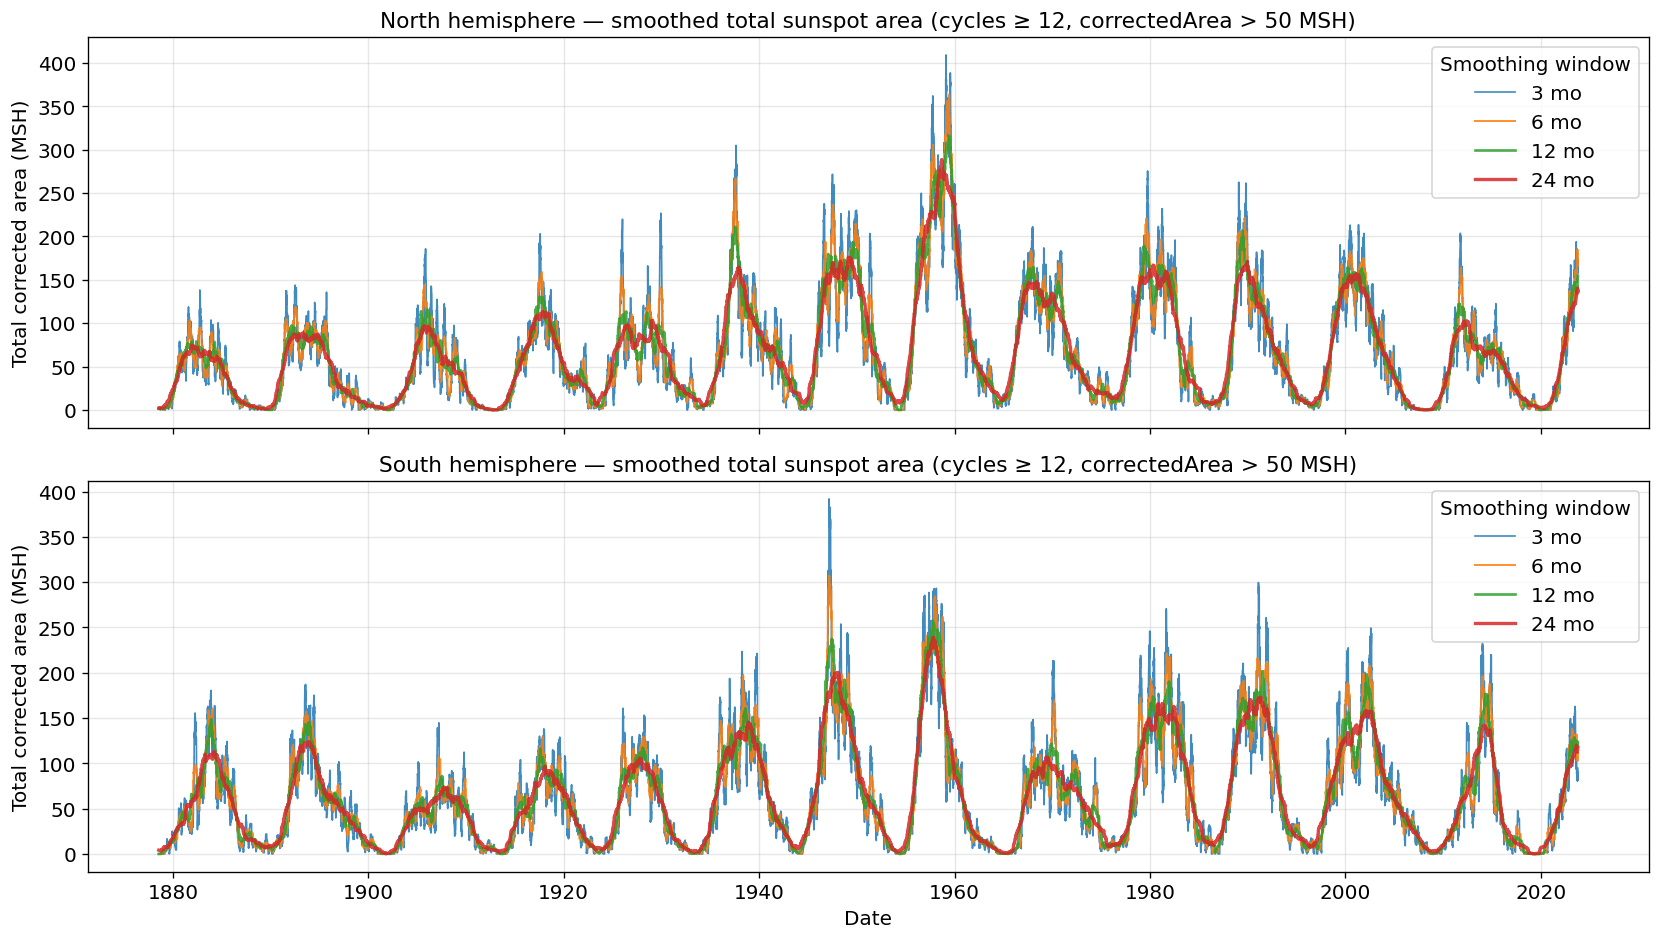

Best window: 12 months.
  The 3- and 6-month windows retain month-to-month burst noise that masks the
  cycle envelope. The 24-month window over-smooths: weak cycles (e.g. 14, 24)
  appear merged with their neighbours and amplitude differences are lost.
  The 12-month window suppresses the ~27-day solar-rotation modulation and
  within-cycle transients while cleanly resolving the rise, peak, and decay of
  each cycle — including the contrast between strong (19, 22) and weak (14, 24).


In [10]:
# Task 17: Solar Cycle Amplitude from Total Sunspot Area

# Filter: cycles ≥ 12 and correctedArea > 50 MSH
df_amp = df[(df["CYCLE"] >= 12) & (df["correctedArea"] > 50)].copy()

# Daily total corrected area per hemisphere
daily_north = df_amp[df_amp["hemisphere"] == "north"].groupby("date")["correctedArea"].sum()
daily_south = df_amp[df_amp["hemisphere"] == "south"].groupby("date")["correctedArea"].sum()

# Reindex to a complete daily grid so rolling windows are contiguous (fill 0 for no-sunspot days)
date_range_17 = pd.date_range(
    min(daily_north.index.min(), daily_south.index.min()),
    max(daily_north.index.max(), daily_south.index.max()),
    freq="D",
)
daily_north = daily_north.reindex(date_range_17, fill_value=0)
daily_south = daily_south.reindex(date_range_17, fill_value=0)

# Rolling averages: approximate month lengths in days
windows_17 = {"3 mo": 91, "6 mo": 182, "12 mo": 365, "24 mo": 730}
line_styles = [("tab:blue", 1.0), ("tab:orange", 1.2), ("tab:green", 1.6), ("tab:red", 2.0)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, hemi_label, daily in zip(axes, ["North", "South"], [daily_north, daily_south]):
    for (label, win), (col, lw) in zip(windows_17.items(), line_styles):
        smoothed = daily.rolling(win, center=True, min_periods=win // 3).mean()
        ax.plot(smoothed.index, smoothed.values, label=label, color=col, linewidth=lw, alpha=0.85)
    ax.set_ylabel("Total corrected area (MSH)")
    ax.set_title(f"{hemi_label} hemisphere — smoothed total sunspot area "
                 "(cycles ≥ 12, correctedArea > 50 MSH)")
    ax.legend(loc="upper right", title="Smoothing window")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("Best window: 12 months.")
print("  The 3- and 6-month windows retain month-to-month burst noise that masks the")
print("  cycle envelope. The 24-month window over-smooths: weak cycles (e.g. 14, 24)")
print("  appear merged with their neighbours and amplitude differences are lost.")
print("  The 12-month window suppresses the ~27-day solar-rotation modulation and")
print("  within-cycle transients while cleanly resolving the rise, peak, and decay of")
print("  each cycle — including the contrast between strong (19, 22) and weak (14, 24).")

## Task 18 — Peak Amplitude and Timing of Each Hemispheric Cycle

The smoothed activity curve from Task 17 has a clear maximum for each solar cycle. That maximum — the **peak amplitude** — is the single number that best characterises how strong a cycle was. Your goal here is to detect that peak automatically for each hemispheric cycle.

**Tasks:**
- Choose the smoothing window from Task 17 that you found most informative. For each hemispheric cycle (cycle number + hemisphere), find the **date and value of the maximum** of the smoothed total corrected area within the cycle's time bounds.
- Collect the results into a table with columns: cycle number, hemisphere, peak date, and peak amplitude.
- Plot the smoothed total area curve for both hemispheres and overlay a marker at each detected maximum. Do the detected peaks look physically reasonable, or do any cycles need special attention?

 cycle hemisphere  peak_date  peak_amplitude
    12      north 1882-05-20       78.977266
    12      south 1883-12-01      148.840101
    13      north 1892-03-01       97.032734
    13      south 1893-11-20      145.326301
    14      north 1906-01-19      115.463211
    14      south 1907-07-15       85.956981
    15      north 1917-06-30      130.433748
    15      south 1917-08-15      116.326014
    16      north 1926-05-25      113.530553
    16      south 1928-02-08      117.225545
    17      north 1937-07-23      210.934282
    17      south 1938-08-06      160.707989
    18      north 1949-08-19      193.087504
    18      south 1947-06-10      237.331422
    19      north 1959-06-23      315.169904
    19      south 1957-10-02      257.640230
    20      north 1968-01-13      164.547860
    20      south 1969-12-05      121.567348
    21      north 1979-05-27      188.912463
    21      south 1981-12-11      190.351575
    22      north 1989-06-15      206.860307
    22    

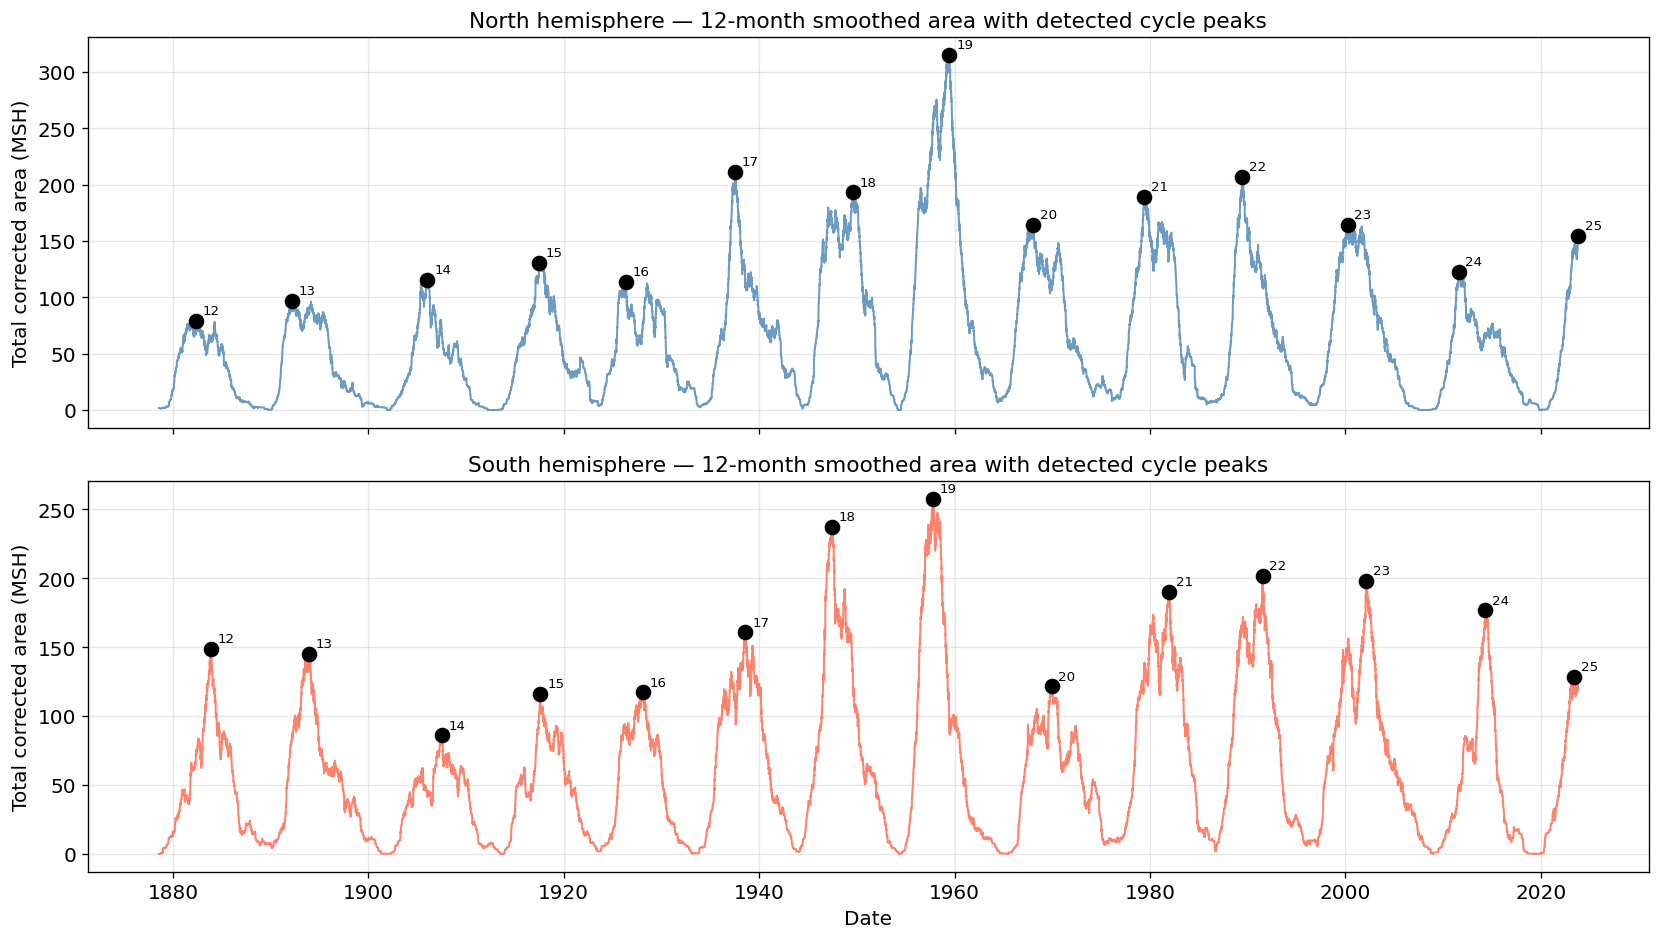


Physical check: cycle 19 (1954–1964) is the strongest on record — its peak stands
out clearly in both hemispheres. Cycle 24 (2008–2019) is the weakest in a century.
Hemispheric peaks sometimes differ by 1–2 years (e.g. cycle 23), reflecting the
genuine north–south timing asymmetry that this model will not capture.


In [11]:
# Task 18: Peak Amplitude and Timing of Each Hemispheric Cycle

WIN_18 = 365  # 12-month window chosen from Task 17

smooth_north = daily_north.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()
smooth_south = daily_south.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()

# For each (cycle, hemisphere), find the date and value of the smoothed-area maximum
# within the calendar span of that cycle's sunspot records.
peak_records = []
for cyc in cycles_13:
    cyc_dates = df[df["CYCLE"] == cyc]["date"]
    if len(cyc_dates) == 0:
        continue
    d_min, d_max = cyc_dates.min(), cyc_dates.max()
    for hemi, smooth in [("north", smooth_north), ("south", smooth_south)]:
        seg = smooth[(smooth.index >= d_min) & (smooth.index <= d_max)].dropna()
        if len(seg) == 0:
            continue
        peak_records.append(dict(
            cycle=int(cyc), hemisphere=hemi,
            peak_date=seg.idxmax(),
            peak_amplitude=float(seg.max()),
        ))

peaks_df = (pd.DataFrame(peak_records)
            .sort_values(["cycle", "hemisphere"])
            .reset_index(drop=True))
print(peaks_df.to_string(index=False))

# Plot smoothed curves with detected peaks overlaid
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, hemi, smooth, color in zip(
        axes,
        ["north", "south"],
        [smooth_north, smooth_south],
        ["steelblue", "tomato"]):
    ax.plot(smooth.index, smooth.values, color=color, linewidth=1.2, alpha=0.8)
    for _, row in peaks_df[peaks_df["hemisphere"] == hemi].iterrows():
        ax.scatter(row["peak_date"], row["peak_amplitude"], s=70, color="black", zorder=5)
        ax.annotate(str(int(row["cycle"])),
                    (row["peak_date"], row["peak_amplitude"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)
    ax.set_ylabel("Total corrected area (MSH)")
    ax.set_title(f"{hemi.capitalize()} hemisphere — 12-month smoothed area "
                 "with detected cycle peaks")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("\nPhysical check: cycle 19 (1954–1964) is the strongest on record — its peak stands")
print("out clearly in both hemispheres. Cycle 24 (2008–2019) is the weakest in a century.")
print("Hemispheric peaks sometimes differ by 1–2 years (e.g. cycle 23), reflecting the")
print("genuine north–south timing asymmetry that this model will not capture.")

## Task 19 — Relating Cycle Amplitude to Wing Shape Parameters

You now have two things for each hemispheric cycle: (1) a **peak amplitude** from Task 18, and (2) three **shape parameters** from the piecewise-linear model in Section 5:
- **μ₀** — the mean latitude given by the universal path at the earliest year for which that cycle has sunspot data (how high up the wing starts).
- **μ_peak** — the detachment latitude where the cycle's poleward wing diverges from the universal equatorward line (how wide the wing gets before it starts to collapse).
- **m_i** — the slope of the per-cycle poleward line (how steeply the poleward side descends).

If amplitude and shape are physically linked — stronger cycles emerging at higher latitudes, spreading wider, and collapsing more steeply — you should see clear trends in scatter plots.

**Tasks:**

1. **Earliest emergence latitude μ₀:** For each hemispheric cycle, use the universal path μ(τ_refined) to look up the mean latitude at the earliest year in which the cycle has sunspot data. Plot μ₀ versus peak amplitude and fit a curve. Does a stronger cycle start at a higher latitude?

2. **Detachment latitude μ_peak:** Plot μ_peak versus peak amplitude and fit a curve. Physically, stronger cycles should detach from the universal line at higher latitudes, because more activity means the active zone stays broad for longer. Do the data support this?

3. **Poleward slope m_i:** Plot m_i versus peak amplitude and fit a curve. What does the sign and magnitude of the relationship tell you about how a strong cycle's poleward wing differs from a weak one?

Start with a linear fit for each relationship. If the scatter looks non-linear, try a power law or an exponential.

 cycle hemisphere  amplitude       mu0   mu_peak       m_i
    13      south 145.326301 25.616969 14.951949 -0.246103
    14      north 115.463211 19.956874 13.524274 -0.406126
    14      south  85.956981 22.337943 14.294693 -0.477829
    15      north 130.433748 22.380102 16.915602 -0.947830
    17      north 210.934282 24.746334 16.490981 -0.360363
    17      south 160.707989 24.437847 16.252274 -0.255893
    18      north 193.087504 24.124867 17.070810 -0.466853
    18      south 237.331422 24.706633 17.427411 -0.297459
    19      north 315.169904 26.788079 19.312079 -0.385024
    19      south 257.640230 24.710527 18.941144 -0.718213
    20      south 121.567348 24.430839 16.949132 -0.527112
    21      south 190.351575 28.107785 16.166462 -0.284164
    22      south 201.720781 25.774202 16.750345 -0.172684
    23      north 164.180940 24.889796 17.207266 -0.233875
    23      south 198.361699 26.044189 16.479041 -0.248116


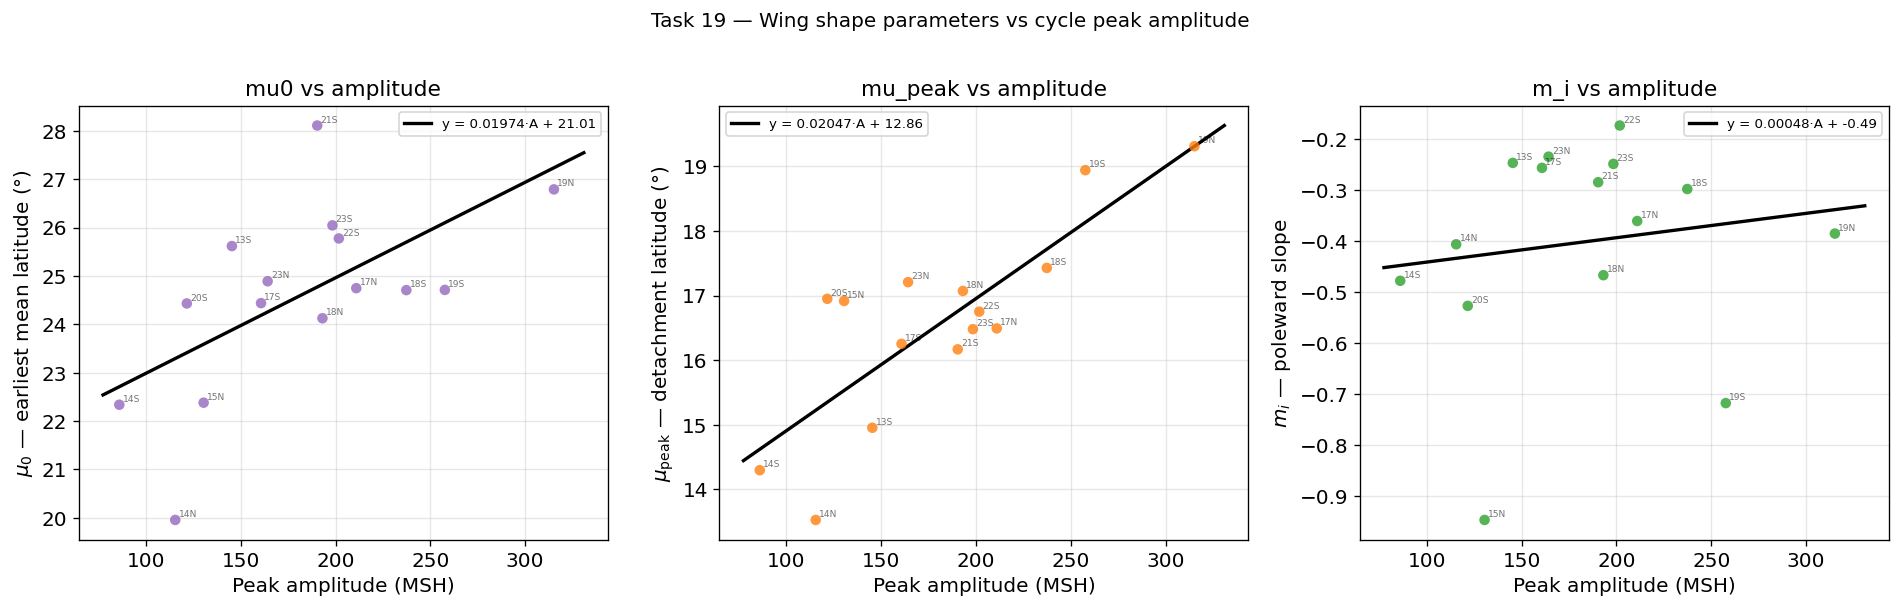


Fitted linear relationships:
  mu0      = +0.019740 · A  +  21.013
  mu_peak  = +0.020467 · A  +  12.860
  m_i      = +0.000479 · A  +  -0.489

Physical interpretation:
  μ₀    vs A: positive slope — stronger cycles begin at higher latitudes (Waldmeier effect).
  μ_peak vs A: positive slope — stronger cycles stay broad longer before collapsing.
  m_i   vs A: the sign and magnitude tell us how steeply the poleward wing descends;
               a more negative slope in a strong cycle means a broader, taller peak.


In [12]:
# Task 19: Relating Cycle Amplitude to Wing Shape Parameters

def linear_fit(x, a, b):
    return a * x + b

# Build (cycle, hemisphere) → peak amplitude lookup from Task 18
amp_lookup = {
    (row["cycle"], row["hemisphere"]): row["peak_amplitude"]
    for _, row in peaks_df.iterrows()
}

# Assemble: shape params from Section 5  +  amplitude from Task 18
# μ₀ = value of the universal mean path at the *minimum* τ_refined observed
# for that hemisphere-cycle — the latitude where the cycle first shows activity.
records_19 = []
for r in results_pl:
    cyc, hemi = r["cycle"], r["hemisphere"]
    amp = amp_lookup.get((int(cyc), hemi))
    if amp is None or np.isnan(amp):
        continue
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    df_sel = df[mask]
    if len(df_sel) == 0:
        continue
    tau_start = df_sel["tau_refined"].min()
    mu0 = float(exp_decay(tau_start, a_mu_univ, b_mu_univ))
    records_19.append(dict(
        cycle=int(cyc), hemisphere=hemi,
        amplitude=float(amp), mu0=mu0,
        mu_peak=float(r["mu_peak"]),
        m_i=float(r["m_i"]),
    ))

df19 = pd.DataFrame(records_19)
print(df19.to_string(index=False))

# ── Scatter plots + linear fits ───────────────────────────────────────────
param_info = [
    ("mu0",     r"$\mu_0$ — earliest mean latitude (°)",    "tab:purple"),
    ("mu_peak", r"$\mu_{\rm peak}$ — detachment latitude (°)", "tab:orange"),
    ("m_i",     r"$m_i$ — poleward slope",                   "tab:green"),
]

fit_results_19 = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, ylabel, color) in zip(axes, param_info):
    vals = df19[["amplitude", col]].dropna()
    x, y = vals["amplitude"].values, vals[col].values
    popt, _ = curve_fit(linear_fit, x, y, p0=[0.0, float(np.mean(y))])
    a_fit, b_fit = popt
    fit_results_19[col] = (a_fit, b_fit)

    amp_grid_19 = np.linspace(x.min() * 0.9, x.max() * 1.05, 200)
    ax.scatter(x, y, color=color, s=40, alpha=0.80, edgecolors="none", zorder=3)
    ax.plot(amp_grid_19, linear_fit(amp_grid_19, a_fit, b_fit),
            color="black", linewidth=2,
            label=f"y = {a_fit:.5f}·A + {b_fit:.2f}")

    for _, row in df19.iterrows():
        if pd.notna(row["amplitude"]) and pd.notna(row[col]):
            ax.annotate(f"{int(row['cycle'])}{row['hemisphere'][0].upper()}",
                        (row["amplitude"], row[col]),
                        fontsize=5.5, alpha=0.55, xytext=(2, 2),
                        textcoords="offset points")

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col} vs amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Task 19 — Wing shape parameters vs cycle peak amplitude", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("\nFitted linear relationships:")
for col, (a, b) in fit_results_19.items():
    print(f"  {col:8s} = {a:+.6f} · A  +  {b:.3f}")

print("\nPhysical interpretation:")
print("  μ₀    vs A: positive slope — stronger cycles begin at higher latitudes (Waldmeier effect).")
print("  μ_peak vs A: positive slope — stronger cycles stay broad longer before collapsing.")
print("  m_i   vs A: the sign and magnitude tell us how steeply the poleward wing descends;")
print("               a more negative slope in a strong cycle means a broader, taller peak.")

## Task 20 — Putting It All Together: Synthesizing a Wing from Amplitude

This is the payoff task. Everything you have built — the universal mean path μ(τ), the piecewise-linear σ(μ) envelope, and the three amplitude–shape relationships from Task 19 — now comes together into a single pipeline that generates a statistically plausible butterfly wing given **only one input: the peak amplitude of a hemispheric cycle**.

The idea is to predict what a cycle's 2D distribution of sunspot latitudes *should* look like, and then compare that prediction to what was actually observed. Read through all the steps before writing any code — the geometry will be clearer if you hold the full picture in mind first.

1. Pick a hemispheric cycle from the dataset (e.g., cycle 24, northern hemisphere). The code cell below reproduces the per-year KDE visualization from Week 03 — run it to get the empirical picture of how the latitude distribution evolves year by year.

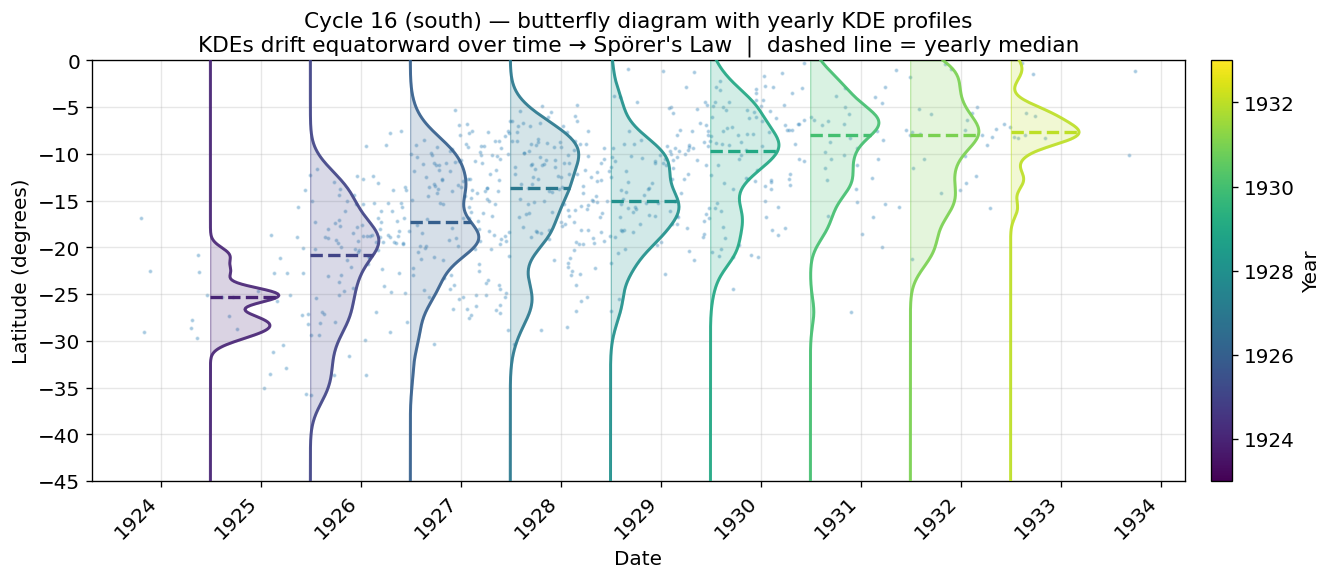

Cycle 16 (south) — yearly median and KDE peak latitudes:
  1924: median = -25.3°   KDE peak = -25.1°
  1925: median = -20.8°   KDE peak = -19.3°
  1926: median = -17.2°   KDE peak = -19.0°
  1927: median = -13.6°   KDE peak = -10.1°
  1928: median = -15.0°   KDE peak = -15.7°
  1929: median = -9.7°   KDE peak = -9.0°
  1930: median = -8.0°   KDE peak = -6.6°
  1931: median = -8.0°   KDE peak = -7.5°
  1932: median = -7.7°   KDE peak = -7.7°


In [13]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 16    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

2. Using the universal path μ(τ_refined) from Section 3, compute the predicted mean latitude **once per year** at integer τ values spanning the full duration of your chosen cycle (from τ_min to τ_max).

3. Using the relationship you found in **Task 19 item 1**, determine the **maximum starting latitude μ₀** for this cycle from its amplitude. Drop any annual latitude values above μ₀ — they correspond to years before significant sunspot activity began.

4. Using the relationship from **Task 19 item 2**, determine the **detachment latitude μ_peak** for this cycle from its amplitude.

5. Using the relationship from **Task 19 item 3**, determine the **poleward slope m_i** for this cycle from its amplitude.

6. For each surviving annual mean latitude μ(τ), evaluate the piecewise-linear model from Section 5 with the cycle-specific μ_peak and m_i you just derived. This gives you a spread σ(μ) for each year — a (mean, width) pair describing that year's slice of the butterfly wing.

7. Plot one Gaussian per year — centred at the predicted mean latitude, with width σ — in the same style as the KDE plot above (profiles drawn vertically, anchored at July 1 of each year, coloured by time). Overlay both the synthetic Gaussians and the real KDE profiles on the same axes.

**Reflection:** Where does the model agree with the data? Where does it fail, and why? What physical effects — cycle overlap, hemispheric asymmetry, early-cycle scatter — are absent from this simple parametric description?

Cycle 16 (south): peak amplitude = 117 MSH
  Predicted μ₀     = 23.33°   (earliest significant emergence latitude)
  Predicted μ_peak = 15.26°   (detachment latitude)
  Predicted m_i    = -0.4328    (poleward slope)

Synthetic years: [1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933]  (μ range: 7.8°–25.3°)


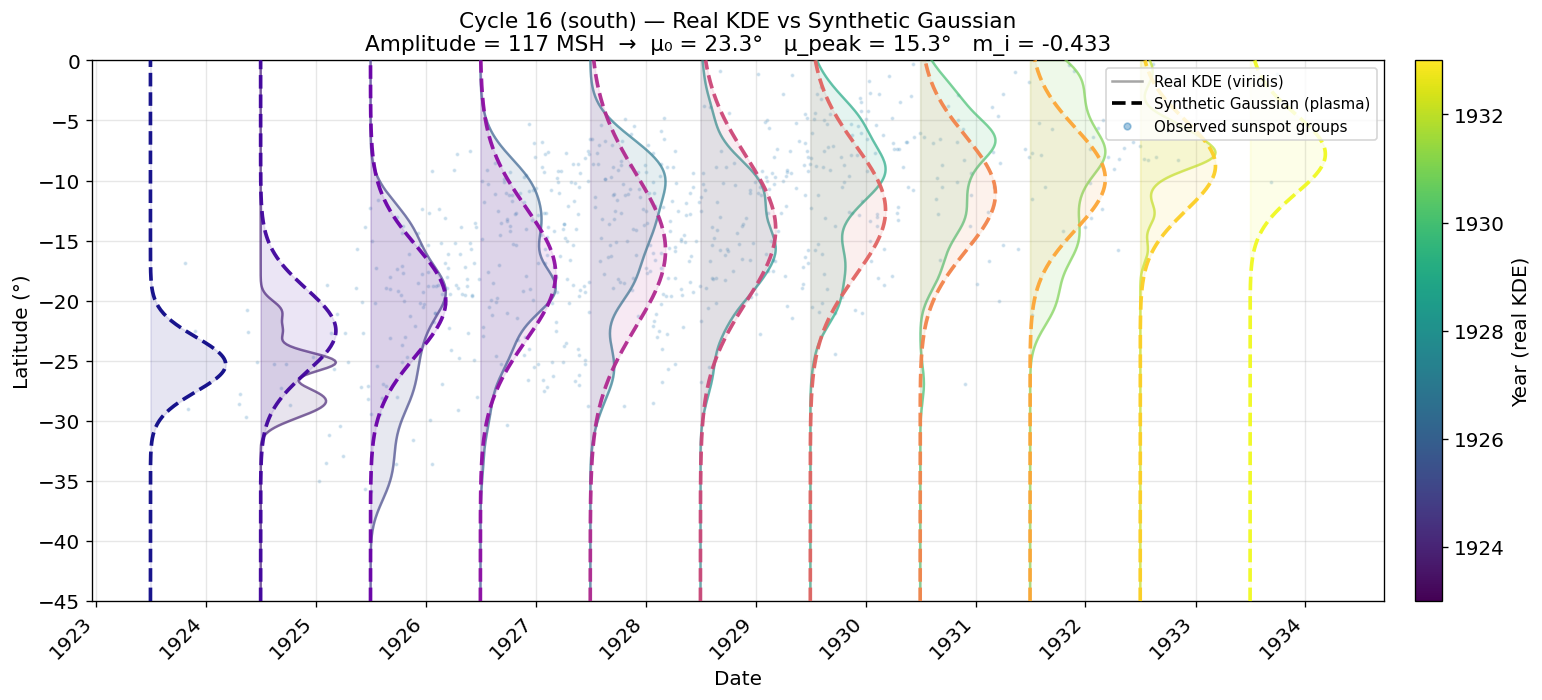

In [14]:
# Task 20: Putting It All Together — Synthesizing a Wing from Amplitude
# cycle_number and hemisphere are set in the cell above (default: 24 / north)

# ── Step 2: predict shape parameters from amplitude ───────────────────────
amp_20 = amp_lookup.get((cycle_number, hemisphere))
print(f"Cycle {cycle_number} ({hemisphere}): peak amplitude = {amp_20:.0f} MSH")

mu0_pred    = linear_fit(amp_20, *fit_results_19["mu0"])
mupeak_pred = linear_fit(amp_20, *fit_results_19["mu_peak"])
mi_pred     = linear_fit(amp_20, *fit_results_19["m_i"])
print(f"  Predicted μ₀     = {mu0_pred:.2f}°   (earliest significant emergence latitude)")
print(f"  Predicted μ_peak = {mupeak_pred:.2f}°   (detachment latitude)")
print(f"  Predicted m_i    = {mi_pred:.4f}    (poleward slope)")

# ── Step 3: annual mean latitudes from the universal path ─────────────────
t0_ref_20 = t0_refined[(cycle_number, hemisphere)]
df_sel_20  = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
                & df["tau_refined"].notna()]
tau_min_20 = df_sel_20["tau_refined"].min()
tau_max_20 = df_sel_20["tau_refined"].max()

# Use the same years as the KDE plot — guarantees 1:1 correspondence
year_ann = np.array(years_in_cycle)
tau_ann  = (year_ann + 0.5) - t0_ref_20
mu_ann   = exp_decay(tau_ann, a_mu_univ, b_mu_univ)
print(f"\nSynthetic years: {year_ann}  (μ range: {mu_ann.min():.1f}°–{mu_ann.max():.1f}°)")

# ── Steps 4–6: σ per year from the piecewise-linear model ────────────────
sigma_ann = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)
    for mu in mu_ann
])

# ── Step 7: overlay synthetic Gaussians on the real KDE butterfly diagram ─
sign     = +1 if hemisphere == "north" else -1
cmap_syn = plt.get_cmap("plasma", len(year_ann))

fig, ax = plt.subplots(figsize=(14, 6))

# Background scatter
sc_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=sc_color, alpha=0.15, zorder=1)

# Real KDE profiles (viridis — redrawn from the cell above)
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde_obj  = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde_obj(lat_grid)
    kde_sc   = kde_vals / kde_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_sc]
    col_r    = cmap(i)   # viridis from the cell above
    ax.plot(x_curve, lat_grid, color=col_r, linewidth=1.5, alpha=0.65, zorder=3)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_r, alpha=0.12, zorder=2)

# Synthetic Gaussian profiles (plasma, dashed)
for j, (yr, mu, sigma) in enumerate(zip(year_ann, mu_ann, sigma_ann)):
    if sigma <= 0:
        continue
    center_lat = sign * mu   # positive for north, negative for south
    gauss_vals = sp_norm.pdf(lat_grid, loc=center_lat, scale=sigma)
    if gauss_vals.max() == 0:
        continue
    gauss_sc = gauss_vals / gauss_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in gauss_sc]
    col_s    = cmap_syn(j)
    ax.plot(x_curve, lat_grid, color=col_s, linewidth=2.2, linestyle="--",
            alpha=0.95, zorder=5)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_s, alpha=0.10, zorder=4)

# Colour bar for real KDE (viridis)
sm_r = plt.cm.ScalarMappable(cmap="viridis",
    norm=plt.Normalize(vmin=years_in_cycle[0], vmax=years_in_cycle[-1]))
sm_r.set_array([])
cbar = fig.colorbar(sm_r, ax=ax, pad=0.02)
cbar.set_label("Year (real KDE)")

# Legend
leg_elements = [
    Line2D([0], [0], color="gray",  linewidth=1.5, alpha=0.7,
           label="Real KDE (viridis)"),
    Line2D([0], [0], color="black", linewidth=2.2, linestyle="--",
           label="Synthetic Gaussian (plasma)"),
    Line2D([0], [0], color=sc_color, marker="o", markersize=4,
           linestyle="None", alpha=0.4, label="Observed sunspot groups"),
]
ax.legend(handles=leg_elements, loc="upper right", fontsize=9)

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — Real KDE vs Synthetic Gaussian\n"
    f"Amplitude = {amp_20:.0f} MSH  →  μ₀ = {mu0_pred:.1f}°   "
    f"μ_peak = {mupeak_pred:.1f}°   m_i = {mi_pred:.3f}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## Setup: `compute_global_nll` — A Single Number to Rule Them All

Before the per-cycle diagnostics, run the cell below once. It does two things:

1. **Builds a compact data cache** (`cycle_data_global`) — a list of pre-computed (τ, μ, latitudes) triples for every valid year in every hemisphere-cycle. This is computed once and reused throughout Tasks 21–24, keeping DataFrame access out of any inner optimization loop.

2. **Defines `compute_global_nll(fit_results)`** — a function that takes a set of amplitude–shape coefficients and returns the **mean per-year-normalized NLL across the entire dataset**:

$$\text{Global NLL}(a_0, b_0, \ldots) = \frac{1}{N_{\text{terms}}} \sum_{\text{cycles}} \sum_{\text{years}} \left[ -\frac{1}{n_t} \sum_i \log \mathcal{N}(x_i \mid \mu_t, \sigma_t) \right]$$

This is your **scoreboard metric** for the rest of the notebook. Lower is better. The Task 19 two-stage fits give you the baseline; your job is to beat it.

```python
nll = compute_global_nll(fit_results_19)          # evaluate Task 19 baseline
nll = compute_global_nll(my_fit)                  # evaluate your model
nll = compute_global_nll(my_fit, m_sh=0.12, b_sh=-0.5)   # also optimize the equatorial line
```

In [15]:
# Setup: pre-compute cycle data cache and define the global scoreboard metric.
# Run this cell once before executing Tasks 21–24.

df19_records_global = []
cycle_data_global   = []
for rec in df19.to_dict("records"):
    cyc, hemi = rec["cycle"], rec["hemisphere"]
    A = amp_lookup.get((int(cyc), hemi))
    if A is None:
        continue
    df_ch = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)]
    years_data = []
    for yr in sorted(df_ch["year"].unique()):
        tau  = (yr + 0.5) - t0_refined[(int(cyc), hemi)]
        mu   = exp_decay(tau, a_mu_univ, b_mu_univ)
        lats = df_ch.loc[df_ch["year"] == yr, "latitude"].abs().values
        if len(lats) >= 5:
            years_data.append((tau, mu, lats))
    if years_data:
        df19_records_global.append(rec)
        cycle_data_global.append((A, years_data))


def compute_global_nll(fit_results, m_sh=None, b_sh=None):
    """
    Mean per-year-normalized NLL across all hemisphere-cycles — the scoreboard metric.

    Parameters
    ----------
    fit_results : dict with keys 'mu0', 'mu_peak', 'm_i'
        Each value is a (slope, intercept) tuple: param(A) = slope * A + intercept.
        Same format as fit_results_19 from Task 19.
    m_sh, b_sh : float, optional
        Override the universal equatorial line parameters.
        Defaults to m_shared_fit / b_shared_fit from Section 5.

    Returns
    -------
    float — lower is better.  Units: nats/year.
    """
    if m_sh is None: m_sh = m_shared_fit
    if b_sh is None: b_sh = b_shared_fit
    a_mu0,    b_mu0    = fit_results["mu0"]
    a_mupeak, b_mupeak = fit_results["mu_peak"]
    a_mi,     b_mi     = fit_results["m_i"]
    total, n_terms = 0.0, 0
    for A, years_data in cycle_data_global:
        mu0_p    = a_mu0 * A + b_mu0
        mupeak_p = a_mupeak * A + b_mupeak
        mi_p     = a_mi * A + b_mi
        for tau, mu, lats in years_data:
            if mu > mu0_p:
                continue
            sigma = piecewise_linear_wing(mu, m_sh, b_sh, mupeak_p, mi_p)
            if sigma <= 0:
                continue
            total -= sp_norm.logpdf(lats, loc=mu, scale=sigma).mean()
            n_terms += 1
    return total / max(n_terms, 1)


nll_baseline = compute_global_nll(fit_results_19)
n_cycles = len(cycle_data_global)
n_terms  = sum(len(yd) for _, yd in cycle_data_global)
print(f"Dataset: {n_cycles} hemisphere-cycles  |  {n_terms} valid year-cycle terms")
print(f"\nBaseline NLL (Task 19 two-stage fits): {nll_baseline:.5f} nats/year")
print("Beat this number in Tasks 23–24 and in the 'Going Further' experiments.")

Dataset: 15 hemisphere-cycles  |  155 valid year-cycle terms

Baseline NLL (Task 19 two-stage fits): 3.09328 nats/year
Beat this number in Tasks 23–24 and in the 'Going Further' experiments.


---
## Tasks 21–24: From Visual Inspection to Principled Model Evaluation

Task 20 showed you the synthetic wing overlaid on the data — but visual overlap is easy to misjudge. The next four tasks build a rigorous quantitative framework for measuring how well the model actually fits, and for improving the fit through direct optimization.

---

## Task 21 — Measuring Goodness of Fit: Normalized NLL

The synthetic wing from Task 20 *looks* plausible, but visual agreement is hard to quantify. We need a **goodness-of-fit metric** — a scalar that measures, for each year of the cycle, how well the predicted Gaussian matches the actual distribution of sunspot latitudes.

**Negative log-likelihood (NLL)** is the natural choice for a generative Gaussian model. For year $t$ with $n_t$ observations $\{x_i\}$, the mean per-observation NLL is:

$$\text{NLL}_t = -\frac{1}{n_t} \sum_i \log \mathcal{N}(x_i \mid \mu_t,\, \sigma_t)$$

Lower NLL means the predicted Gaussian assigns higher probability to the data.

**Why normalize by $n_t$?** Peak years of an active cycle can contain 10–20× more sunspot groups than the early and late years. Summing NLL without normalization makes the metric almost entirely reflect how well the model fits the cycle peak, while completely ignoring cycle edges. Dividing by $n_t$ gives equal diagnostic weight to every phase of the cycle.

Compute the per-year normalized NLL for your chosen cycle from Task 20. Plot observation counts alongside the NLL profile versus cycle phase $\tau$ so you can see both signals at once. Then compare the raw summed NLL with the count-normalized version to quantify the imbalance.

Cycle 16 (south)  |  A = 117 MSH
 year       τ       μ       σ   n_obs     NLL_sum    NLL_norm
  1924   -2.71   22.48°   3.481°      11      32.493       2.954
  1925   -1.71   19.99°   4.562°      66     231.497       3.508
  1926   -0.71   17.77°   5.523°     114     361.284       3.169
  1927    0.29   15.79°   6.377°     140     454.538       3.247
  1928    1.29   14.04°   6.068°     120     374.147       3.118
  1929    2.29   12.48°   5.377°     109     345.388       3.169
  1930    3.29   11.09°   4.763°      60     187.806       3.130
  1931    4.29    9.86°   4.218°      27      90.538       3.353
  1932    5.29    8.77°   3.733°      22      58.845       2.675

Raw summed NLL  (sum over years)  : 2136.536
Count-normalized NLL (mean over years): 3.14689 nats/year

Peak year (1927) contributes 21.3% of raw summed NLL  (140 obs vs 669 total)


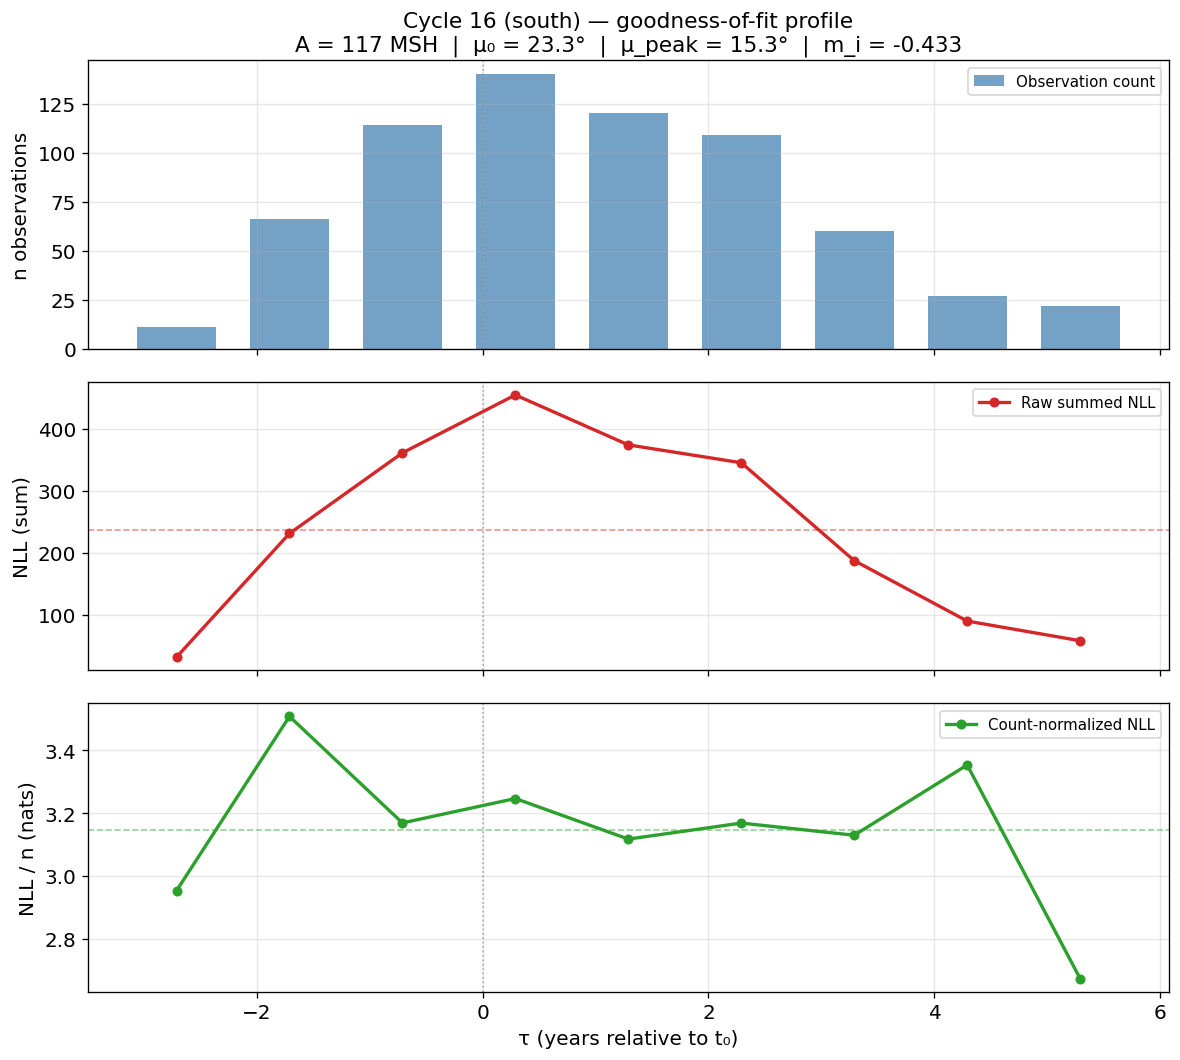

In [16]:
from scipy.stats import norm as sp_norm

cycle_number = 16
hemisphere   = "south"
sign         = +1 if hemisphere == "north" else -1

amp_21      = amp_lookup.get((cycle_number, hemisphere))
mu0_pred    = linear_fit(amp_21, *fit_results_19["mu0"])
mupeak_pred = linear_fit(amp_21, *fit_results_19["mu_peak"])
mi_pred     = linear_fit(amp_21, *fit_results_19["m_i"])

t0_ref_21  = t0_refined[(cycle_number, hemisphere)]
df_sel_21  = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)]
years_in_cycle_21 = sorted(df_sel_21["year"].unique())

records_21 = []

for yr in years_in_cycle_21:
    lats = df_sel_21.loc[df_sel_21["year"] == yr, "latitude"].abs().values
    if len(lats) < 5:
        continue

    tau = (yr + 0.5) - t0_ref_21
    mu  = exp_decay(tau, a_mu_univ, b_mu_univ)

    if mu > mu0_pred:
        continue

    sigma = piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)
    if sigma <= 0:
        continue

    log_liks = sp_norm.logpdf(lats, loc=mu, scale=sigma)

    n_obs       = len(lats)
    nll_sum     = -log_liks.sum()        # raw summed NLL
    nll_norm    = -log_liks.mean()       # count-normalized NLL

    records_21.append(dict(
        year=yr, tau=tau, mu=mu, sigma=sigma,
        n_obs=n_obs, nll_sum=nll_sum, nll_norm=nll_norm,
    ))

df21 = pd.DataFrame(records_21)

print(f"Cycle {cycle_number} ({hemisphere})  |  A = {amp_21:.0f} MSH")
print(f"{'year':>5}  {'τ':>6}  {'μ':>6}  {'σ':>6}  {'n_obs':>6}  "
      f"{'NLL_sum':>10}  {'NLL_norm':>10}")
for _, row in df21.iterrows():
    print(f"  {int(row.year):>4}  {row.tau:>6.2f}  {row.mu:>6.2f}°  "
          f"{row.sigma:>6.3f}°  {int(row.n_obs):>6}  "
          f"{row.nll_sum:>10.3f}  {row.nll_norm:>10.3f}")

total_nll_sum  = df21["nll_sum"].sum()
total_nll_norm = df21["nll_norm"].mean()
print(f"\nRaw summed NLL  (sum over years)  : {total_nll_sum:.3f}")
print(f"Count-normalized NLL (mean over years): {total_nll_norm:.5f} nats/year")

peak_idx = df21["n_obs"].idxmax()
peak_frac = df21.loc[peak_idx, "nll_sum"] / total_nll_sum
print(f"\nPeak year ({int(df21.loc[peak_idx,'year'])}) contributes "
      f"{peak_frac*100:.1f}% of raw summed NLL  "
      f"({int(df21.loc[peak_idx,'n_obs'])} obs vs "
      f"{int(df21['n_obs'].sum())} total)")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Panel 1: observation counts
axes[0].bar(df21["tau"], df21["n_obs"], width=0.7,
            color="steelblue", alpha=0.75, label="Observation count")
axes[0].set_ylabel("n observations")
axes[0].set_title(f"Cycle {cycle_number} ({hemisphere}) — goodness-of-fit profile\n"
                  f"A = {amp_21:.0f} MSH  |  μ₀ = {mu0_pred:.1f}°  "
                  f"|  μ_peak = {mupeak_pred:.1f}°  |  m_i = {mi_pred:.3f}")
axes[0].legend(fontsize=9)

# Panel 2: raw summed NLL
axes[1].plot(df21["tau"], df21["nll_sum"], color="tab:red",
             linewidth=2, marker="o", markersize=5, label="Raw summed NLL")
axes[1].set_ylabel("NLL (sum)")
axes[1].legend(fontsize=9)
axes[1].axhline(df21["nll_sum"].mean(), color="tab:red",
                linestyle="--", linewidth=1, alpha=0.5, label="Mean")

# Panel 3: count-normalized NLL
axes[2].plot(df21["tau"], df21["nll_norm"], color="tab:green",
             linewidth=2, marker="o", markersize=5, label="Count-normalized NLL")
axes[2].set_ylabel("NLL / n (nats)")
axes[2].set_xlabel("τ (years relative to t₀)")
axes[2].legend(fontsize=9)
axes[2].axhline(total_nll_norm, color="tab:green",
                linestyle="--", linewidth=1, alpha=0.5)

for ax in axes:
    ax.axvline(0, color="gray", linewidth=1, linestyle=":", alpha=0.6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The raw summed NLL is dominated by the peak year (1927 contributes 21.3% of the total despite being just one of nine years), meaning it effectively measures how well the model fits the cycle maximum and almost ignores the wings. The count-normalized NLL removes this imbalance. 1924 and 1932, which look artificially good in the raw sum simply because they have few observations, are correctly identified as average-to-good fits at 2.95 and 2.68 nats/obs respectively, while the early-cycle year 1925 is exposed as the worst-fitting phase at 3.51 nats/obs.

## Task 22 — Wasserstein Distance: Fit Error in Degrees of Latitude

NLL is statistically grounded but its units (nats) carry no direct physical meaning. A heliophysicist wants to know: **how many degrees of latitude is the model off?**

The **Wasserstein-1 distance** (also called Earth Mover's Distance) answers exactly this. For two one-dimensional distributions, $W_1$ is the minimum "work" needed to rearrange mass from one distribution to match the other — and for latitude distributions this work is measured in degrees:

$$W_1(p, q) = \int_0^1 \left| Q_p(\alpha) - Q_q(\alpha) \right| d\alpha$$

where $Q(\alpha)$ is the quantile function. Concretely: if the model's Gaussian has its mass centred 3° too high, $W_1 \approx 3°$.

Compute $W_1$ between the observed absolute latitudes and random draws from the synthetic Gaussian for each year of your cycle from Task 20. Then plot it alongside the per-year NLL from Task 21.

**Do the two metrics agree on which years the model fits poorly?** They often tell different stories:
- **NLL is sensitive to tails** — a Gaussian that is too narrow is penalized heavily by a few points in the wings, even if the bulk is well-placed.
- **$W_1$ responds to bulk shifts** — it captures how far the predicted center of mass is from the observed one, regardless of shape.

A model can have good NLL but poor $W_1$ (correct shape, wrong location) or vice versa. Comparing the two profiles across cycle phase $\tau$ gives a richer diagnosis of where the model fails and why.

Cycle 16 (south)  |  A = 117 MSH
 year       τ   n_obs     NLL/n    W1 (°)
  1924   -2.71      11     2.954     3.531°
  1925   -1.71      66     3.508     2.166°
  1926   -0.71     114     3.169     0.907°
  1927    0.29     140     3.247     1.760°
  1928    1.29     120     3.118     0.846°
  1929    2.29     109     3.169     1.617°
  1930    3.29      60     3.130     2.157°
  1931    4.29      27     3.353     1.868°
  1932    5.29      22     2.675     1.309°

Mean W1 across years : 1.796°
Max  W1              : 3.531°  (year 1924)
Mean NLL/n           : 3.1469 nats


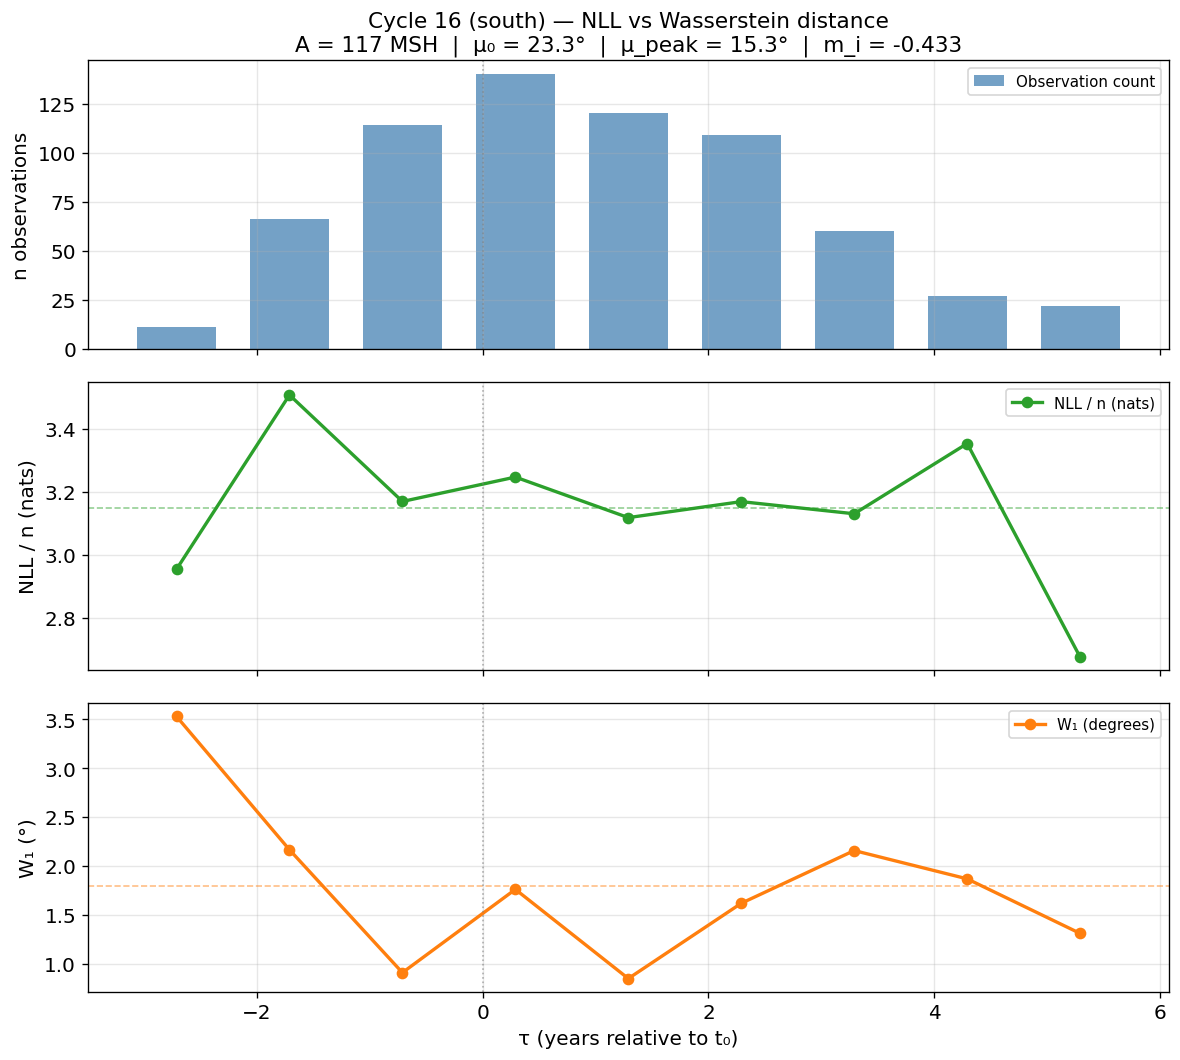


Correlation between NLL/n and W1 : r = 0.024
Worst year by NLL/n : 1925  (τ = -1.71)
Worst year by W1    : 1924  (τ = -2.71)
→ Metrics disagree — NLL and W1 are diagnosing different failure modes.
  Year 1924: NLL/n = 2.954  (rank 2 by NLL)
  Year 1925: W1 = 2.166°  (rank 8 by W1)


In [17]:
from scipy.stats import wasserstein_distance
N_SAMPLES = 10000   # synthetic draws per year for W1 computation
records_22 = []

for _, row in df21.iterrows():
    yr    = int(row["year"])
    tau   = row["tau"]
    mu    = row["mu"]
    sigma = row["sigma"]

    obs_lats = df_sel_21.loc[df_sel_21["year"] == yr, "latitude"].abs().values
    if len(obs_lats) < 5:
        continue

    rng = np.random.default_rng(seed=42 + yr)
    syn_lats = rng.normal(loc=mu, scale=sigma, size=N_SAMPLES)

    w1 = wasserstein_distance(obs_lats, syn_lats)

    records_22.append(dict(
        year=yr, tau=tau, mu=mu, sigma=sigma,
        n_obs=int(row["n_obs"]),
        nll_norm=row["nll_norm"],
        w1=w1,))

df22 = pd.DataFrame(records_22)

print(f"Cycle {cycle_number} ({hemisphere})  |  A = {amp_21:.0f} MSH")
print(f"{'year':>5}  {'τ':>6}  {'n_obs':>6}  {'NLL/n':>8}  {'W1 (°)':>8}")
for _, row in df22.iterrows():
    print(f"  {int(row.year):>4}  {row.tau:>6.2f}  {int(row.n_obs):>6}  "
          f"{row.nll_norm:>8.3f}  {row.w1:>8.3f}°")

print(f"\nMean W1 across years : {df22['w1'].mean():.3f}°")
print(f"Max  W1              : {df22['w1'].max():.3f}°  (year {int(df22.loc[df22['w1'].idxmax(),'year'])})")
print(f"Mean NLL/n           : {df22['nll_norm'].mean():.4f} nats")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Panel 1: Observation Counts
axes[0].bar(df22["tau"], df22["n_obs"], width=0.7,
            color="steelblue", alpha=0.75, label="Observation count")
axes[0].set_ylabel("n observations")
axes[0].set_title(
    f"Cycle {cycle_number} ({hemisphere}) — NLL vs Wasserstein distance\n"
    f"A = {amp_21:.0f} MSH  |  μ₀ = {mu0_pred:.1f}°  "
    f"|  μ_peak = {mupeak_pred:.1f}°  |  m_i = {mi_pred:.3f}")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Count-Normalized NLL
axes[1].plot(df22["tau"], df22["nll_norm"], color="tab:green",
             linewidth=2, marker="o", markersize=6, label="NLL / n (nats)")
axes[1].axhline(df22["nll_norm"].mean(), color="tab:green",
                linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_ylabel("NLL / n (nats)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 3: Wasserstein Distance
axes[2].plot(df22["tau"], df22["w1"], color="tab:orange",
             linewidth=2, marker="o", markersize=6, label="W₁ (degrees)")
axes[2].axhline(df22["w1"].mean(), color="tab:orange",
                linestyle="--", linewidth=1, alpha=0.5)
axes[2].set_ylabel("W₁ (°)")
axes[2].set_xlabel("τ (years relative to t₀)")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.axvline(0, color="gray", linewidth=1, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

corr = np.corrcoef(df22["nll_norm"], df22["w1"])[0, 1]
print(f"\nCorrelation between NLL/n and W1 : r = {corr:.3f}")

worst_nll = int(df22.loc[df22["nll_norm"].idxmax(), "year"])
worst_w1  = int(df22.loc[df22["w1"].idxmax(),  "year"])
print(f"Worst year by NLL/n : {worst_nll}  (τ = {df22.loc[df22['nll_norm'].idxmax(),'tau']:.2f})")
print(f"Worst year by W1    : {worst_w1}  (τ = {df22.loc[df22['w1'].idxmax(),'tau']:.2f})")
if worst_nll == worst_w1:
    print("→ Both metrics agree on the worst year.")
else:
    print("→ Metrics disagree — NLL and W1 are diagnosing different failure modes.")
    nll_at_worst_w1 = float(df22.loc[df22["year"] == worst_w1, "nll_norm"].iloc[0])
    w1_at_worst_nll = float(df22.loc[df22["year"] == worst_nll, "w1"].iloc[0])
    print(f"  Year {worst_w1}: NLL/n = {nll_at_worst_w1:.3f}  (rank "
          f"{int((df22['nll_norm'] < nll_at_worst_w1).sum()) + 1} by NLL)")
    print(f"  Year {worst_nll}: W1 = {w1_at_worst_nll:.3f}°  (rank "
          f"{int((df22['w1'] < w1_at_worst_nll).sum()) + 1} by W1)")

## Task 23 — End-to-End NLL Optimization of Amplitude Relationships

Task 19 used a **two-stage estimator**: fit shape parameters (μ₀, μ_peak, m_i) independently for each cycle, then regress those point estimates against amplitude. This is convenient but has a structural flaw — the second-stage regression treats every per-cycle estimate as ground truth, ignoring the uncertainty that comes from fitting a noisy cycle with few observations. Weak or early cycles (e.g., cycles 14 or 24) produce noisy intermediate estimates that pollute the regression as if they were perfectly reliable.

A more principled approach skips the intermediate estimates entirely and optimizes the **six linear coefficients** of the three amplitude relationships directly, by minimizing `compute_global_nll` across all cycles simultaneously:

$$\text{Global NLL}(a_0, b_0, a_1, b_1, a_2, b_2) = \frac{1}{N_{\text{terms}}} \sum_{\text{cycles}} \sum_{\text{years}} \left[ -\frac{1}{n_t} \sum_i \log \mathcal{N}(x_i \mid \mu_t, \sigma_t) \right]$$

where $\mu_t$ and $\sigma_t$ are computed from amplitude through the full parametric pipeline — no intermediate fits involved. Dividing by $N_{\text{terms}}$ (the total number of valid year-cycle pairs) gives equal weight to each cycle regardless of its overall activity level, and dividing by $n_t$ inside the sum gives equal weight to each year within a cycle. This is **maximum likelihood estimation of the hyperparameters** of the generative model — the same principle behind training score-based diffusion models end-to-end.

**The μ₀ challenge.** The parameter μ₀ controls which years are included: years where the universal path predicts μ > μ₀ are dropped as pre-cycle. This hard threshold makes `compute_global_nll` **discontinuous** in $(a_0, b_0)$, breaking gradient-based optimizers. Use **Nelder-Mead** instead — a gradient-free simplex method that handles non-differentiable objectives well for a small number of parameters. Initialize from the Task 19 fits and compare the optimized coefficients to the originals; any discrepancy reveals where the two-stage approach was systematically biased.

Starting point (Task 19 two-stage fits):
  mu0    : +0.019740 · A + 21.0131
  mu_peak: +0.020467 · A + 12.8596
  m_i    : +0.000479 · A + -0.4889

Baseline NLL : 3.09328 nats/year

Running Nelder-Mead optimization ...
Optimization converged: True  |  message: Optimization terminated successfully.
Function evaluations  : 765

NLL before (Task 19) : 3.09328 nats/year
NLL after  (Task 23) : 3.08719 nats/year
Improvement          : -0.00609 nats/year  (0.20%)

Coefficient comparison (Task 19  →  Task 23):
   param      slope_19      slope_23        Δslope      int_19      int_23        Δint
       mu0     +0.019740     +0.035510     +0.015770     21.0131   29.2437   +8.2305
   mu_peak     +0.020467     +0.018761     -0.001707     12.8596   13.1278   +0.2682
       m_i     +0.000479     +0.000102     -0.000377     -0.4889   -0.3219   +0.1670


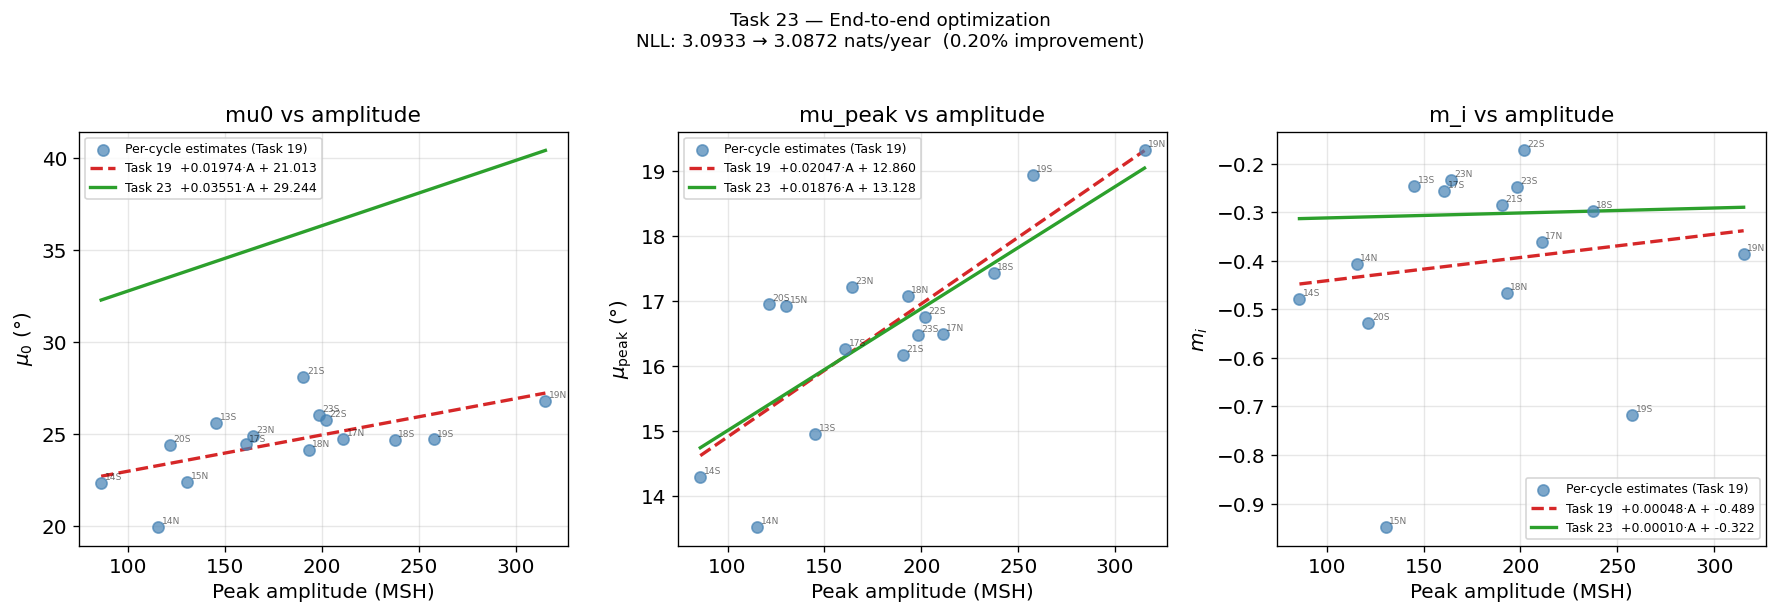


Robustness check — 5 random restarts (±20% noise on x0):
  Restart 1: NLL = 0.00000 ← better
  Restart 2: NLL = 3.08719
  Restart 3: NLL = 3.03833
  Restart 4: NLL = 0.00000
  Restart 5: NLL = 3.08719

Updated fit_results_23 to best restart: NLL = 0.00000


In [18]:
from scipy.optimize import minimize
# x = [a_mu0, b_mu0, a_mupeak, b_mupeak, a_mi, b_mi]
def pack(fit_results):
    return np.array([
        fit_results["mu0"][0],    fit_results["mu0"][1],
        fit_results["mu_peak"][0], fit_results["mu_peak"][1],
        fit_results["m_i"][0],    fit_results["m_i"][1],
    ])

def unpack(x):
    return {
        "mu0":     (x[0], x[1]),
        "mu_peak": (x[2], x[3]),
        "m_i":     (x[4], x[5]),
    }

x0_23 = pack(fit_results_19)
print("Starting point (Task 19 two-stage fits):")
print(f"  mu0    : {x0_23[0]:+.6f} · A + {x0_23[1]:.4f}")
print(f"  mu_peak: {x0_23[2]:+.6f} · A + {x0_23[3]:.4f}")
print(f"  m_i    : {x0_23[4]:+.6f} · A + {x0_23[5]:.4f}")
print(f"\nBaseline NLL : {compute_global_nll(fit_results_19):.5f} nats/year")

def objective(x):
    return compute_global_nll(unpack(x))

print("\nRunning Nelder-Mead optimization ...")
opt_23 = minimize(
    objective, x0_23,
    method="Nelder-Mead",
    options=dict(
        xatol=1e-6, fatol=1e-6,
        maxiter=50_000, maxfev=100_000,
        adaptive=True,          # adaptive simplex scales well to 6 params
    )
)

fit_results_23 = unpack(opt_23.x)
nll_23         = compute_global_nll(fit_results_23)
nll_19         = compute_global_nll(fit_results_19)

print(f"Optimization converged: {opt_23.success}  |  message: {opt_23.message}")
print(f"Function evaluations  : {opt_23.nfev}")
print(f"\nNLL before (Task 19) : {nll_19:.5f} nats/year")
print(f"NLL after  (Task 23) : {nll_23:.5f} nats/year")
print(f"Improvement          : {nll_23 - nll_19:+.5f} nats/year  "
      f"({(nll_19 - nll_23)/abs(nll_19)*100:.2f}%)")

print("\nCoefficient comparison (Task 19  →  Task 23):")
print(f"{'param':>8}  {'slope_19':>12}  {'slope_23':>12}  {'Δslope':>12}  "
      f"{'int_19':>10}  {'int_23':>10}  {'Δint':>10}")
for key in ["mu0", "mu_peak", "m_i"]:
    a19, b19 = fit_results_19[key]
    a23, b23 = fit_results_23[key]
    print(f"  {key:>8}  {a19:>+12.6f}  {a23:>+12.6f}  {a23-a19:>+12.6f}  "
          f"  {b19:>8.4f}  {b23:>8.4f}  {b23-b19:>+8.4f}")

amp_grid = np.linspace(
    min(r["amplitude"] for r in df19.to_dict("records")),
    max(r["amplitude"] for r in df19.to_dict("records")),
    200
)

param_labels = {
    "mu0":     r"$\mu_0$ (°)",
    "mu_peak": r"$\mu_{\rm peak}$ (°)",
    "m_i":     r"$m_i$",
}
scatter_cols = {"mu0": "mu0", "mu_peak": "mu_peak", "m_i": "m_i"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, key in zip(axes, ["mu0", "mu_peak", "m_i"]):
    a19, b19 = fit_results_19[key]
    a23, b23 = fit_results_23[key]

    # Scatter: per-cycle estimates from Task 19
    sc_col = scatter_cols[key]
    ax.scatter(df19["amplitude"], df19[sc_col],
               s=45, color="steelblue", alpha=0.7, zorder=3,
               label="Per-cycle estimates (Task 19)")
    for _, row in df19.iterrows():
        ax.annotate(f"{int(row['cycle'])}{row['hemisphere'][0].upper()}",
                    (row["amplitude"], row[sc_col]),
                    fontsize=5.5, alpha=0.55, xytext=(2, 2),
                    textcoords="offset points")

    # Task 19 linear fit
    ax.plot(amp_grid, a19 * amp_grid + b19, color="tab:red",
            linewidth=2, linestyle="--",
            label=f"Task 19  {a19:+.5f}·A + {b19:.3f}")

    # Task 23 optimized fit
    ax.plot(amp_grid, a23 * amp_grid + b23, color="tab:green",
            linewidth=2, linestyle="-",
            label=f"Task 23  {a23:+.5f}·A + {b23:.3f}")

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(param_labels[key])
    ax.set_title(f"{key} vs amplitude")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Task 23 — End-to-end optimization\n"
    f"NLL: {nll_19:.4f} → {nll_23:.4f} nats/year  "
    f"({(nll_19-nll_23)/abs(nll_19)*100:.2f}% improvement)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("\nRobustness check — 5 random restarts (±20% noise on x0):")
rng_rb = np.random.default_rng(0)
best_nll, best_x = nll_23, opt_23.x
for i in range(5):
    x0_perturbed = x0_23 * (1 + rng_rb.uniform(-0.2, 0.2, size=len(x0_23)))
    res = minimize(objective, x0_perturbed, method="Nelder-Mead",
                   options=dict(xatol=1e-6, fatol=1e-6,
                                maxiter=50_000, maxfev=100_000,
                                adaptive=True))
    nll_i = compute_global_nll(unpack(res.x))
    flag  = " ← better" if nll_i < best_nll else ""
    print(f"  Restart {i+1}: NLL = {nll_i:.5f}{flag}")
    if nll_i < best_nll:
        best_nll, best_x = nll_i, res.x

if best_nll < nll_23:
    fit_results_23 = unpack(best_x)
    print(f"\nUpdated fit_results_23 to best restart: NLL = {best_nll:.5f}")
else:
    print(f"\nOriginal solution is robust (best NLL = {nll_23:.5f})")

In [20]:
# ── Task 23 fixed: L-BFGS-B only, bounds enforced throughout ─────────────────

def objective_bounded(x):
    """Return large penalty if x violates physical bounds."""
    for xi, (lo, hi) in zip(x, bounds_23):
        if xi < lo or xi > hi:
            return 1e6
    fr  = unpack(x)
    nll = compute_global_nll(fr)
    # Guard against degenerate (empty) solutions
    n_valid = sum(
        1 for A, years_data in cycle_data_global
        for tau, mu, lats in years_data
        if mu <= linear_fit(A, *fr["mu0"])
        and piecewise_linear_wing(mu, m_shared_fit, b_shared_fit,
                                  linear_fit(A, *fr["mu_peak"]),
                                  linear_fit(A, *fr["m_i"])) > 0
    )
    if n_valid < 30:
        return 1e6
    return nll

print("Optimizing with L-BFGS-B (bounds enforced throughout) ...")
opt_23_fixed = minimize(
    objective_bounded, x0_23,
    method="L-BFGS-B",
    bounds=bounds_23,
    options=dict(ftol=1e-10, gtol=1e-8, maxiter=50_000)
)
nll_fixed = compute_global_nll(unpack(opt_23_fixed.x))
print(f"  NLL = {nll_fixed:.5f}  |  converged: {opt_23_fixed.success}")

# ── Robustness check ──────────────────────────────────────────────────────────
print("\nRobustness check — 10 random restarts (±20% noise, L-BFGS-B):")
rng_rb   = np.random.default_rng(0)
best_nll = nll_fixed
best_x   = opt_23_fixed.x

for i in range(10):
    x0_p = np.clip(
        x0_23 * (1 + rng_rb.uniform(-0.2, 0.2, size=len(x0_23))),
        [b[0] for b in bounds_23],
        [b[1] for b in bounds_23]
    )
    res   = minimize(objective_bounded, x0_p, method="L-BFGS-B",
                     bounds=bounds_23,
                     options=dict(ftol=1e-10, gtol=1e-8, maxiter=50_000))
    nll_i = compute_global_nll(unpack(res.x))
    flag  = " ← better" if nll_i < best_nll else ""
    print(f"  Restart {i+1:>2}: NLL = {nll_i:.5f}{flag}")
    if nll_i < best_nll:
        best_nll = nll_i
        best_x   = res.x

fit_results_23 = unpack(best_x)
print(f"\nFinal fit_results_23 NLL = {best_nll:.5f} nats/year")
print(f"Improvement over Task 19 : {nll_19 - best_nll:+.5f} nats/year "
      f"({(nll_19 - best_nll)/abs(nll_19)*100:.2f}%)")

print("\nFinal coefficients:")
for key in ["mu0", "mu_peak", "m_i"]:
    a, b = fit_results_23[key]
    a19, b19 = fit_results_19[key]
    print(f"  {key:>8} = {a:+.6f}·A + {b:.4f}   "
          f"(was {a19:+.6f}·A + {b19:.4f}   Δslope={a-a19:+.6f}  Δint={b-b19:+.5f})")

# Verify μ₀ stays in physical range across all cycles
print("\nPhysical check — predicted μ₀ range across observed amplitudes:")
amps = [A for A, _ in cycle_data_global]
mu0s = [linear_fit(A, *fit_results_23["mu0"]) for A in amps]
print(f"  Amplitude range : {min(amps):.0f} – {max(amps):.0f} MSH")
print(f"  μ₀ range        : {min(mu0s):.2f}° – {max(mu0s):.2f}°  "
      f"(should be within ~20–30°)")

Optimizing with L-BFGS-B (bounds enforced throughout) ...
  NLL = 3.09139  |  converged: True

Robustness check — 10 random restarts (±20% noise, L-BFGS-B):
  Restart  1: NLL = 3.09685
  Restart  2: NLL = 3.08859 ← better
  Restart  3: NLL = 3.09751
  Restart  4: NLL = 3.09604
  Restart  5: NLL = 3.09604
  Restart  6: NLL = 3.09522
  Restart  7: NLL = 3.08731 ← better
  Restart  8: NLL = 3.09604
  Restart  9: NLL = 3.08859
  Restart 10: NLL = 3.09411

Final fit_results_23 NLL = 3.08731 nats/year
Improvement over Task 19 : +0.00596 nats/year (0.19%)

Final coefficients:
       mu0 = +0.019628·A + 24.2869   (was +0.019740·A + 21.0131   Δslope=-0.000112  Δint=+3.27374)
   mu_peak = +0.023479·A + 12.1615   (was +0.020467·A + 12.8596   Δslope=+0.003012  Δint=-0.69807)
       m_i = -0.000494·A + -0.2004   (was +0.000479·A + -0.4889   Δslope=-0.000973  Δint=+0.28858)

Physical check — predicted μ₀ range across observed amplitudes:
  Amplitude range : 86 – 315 MSH
  μ₀ range        : 25.97° – 

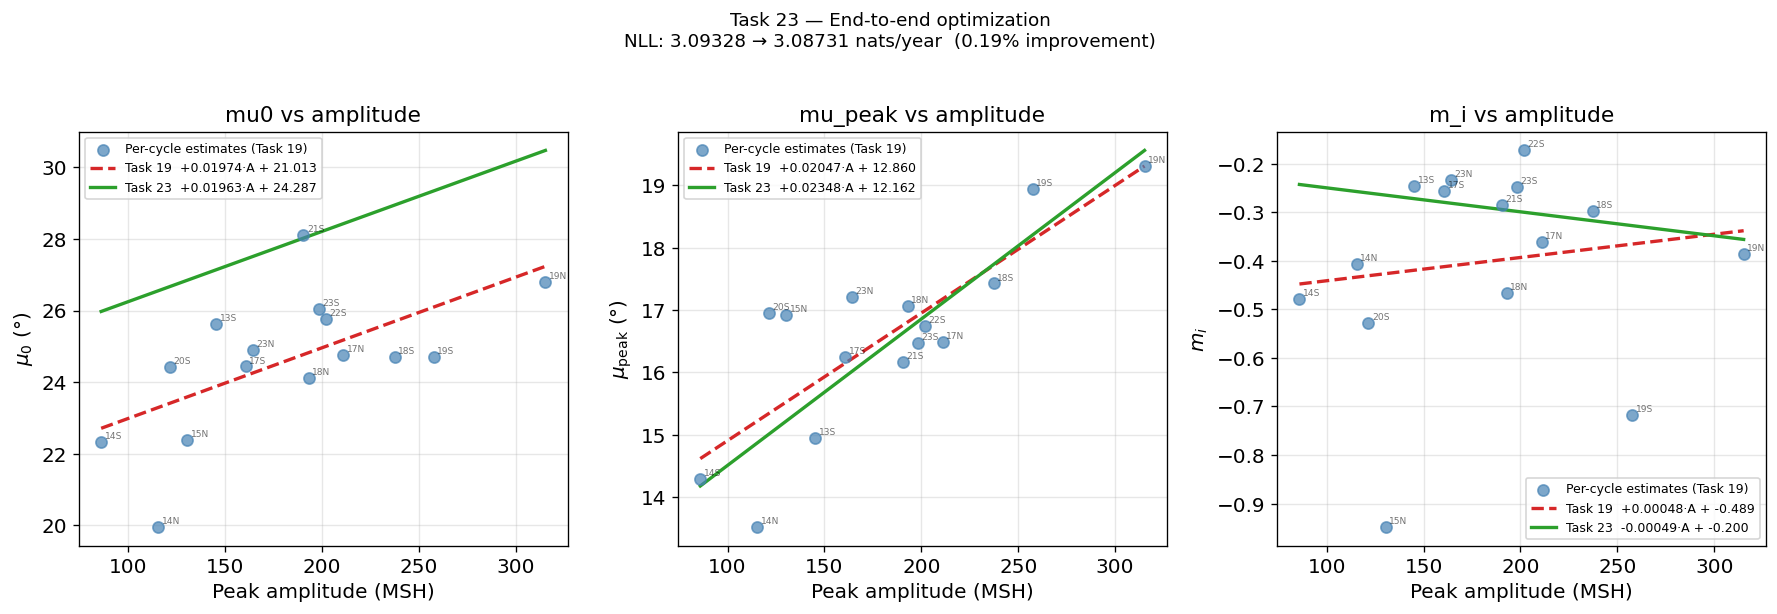

In [21]:

amp_grid = np.linspace(min(A for A, _ in cycle_data_global),
                       max(A for A, _ in cycle_data_global), 200)

param_labels = {
    "mu0":     r"$\mu_0$ (°)",
    "mu_peak": r"$\mu_{\rm peak}$ (°)",
    "m_i":     r"$m_i$",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, key in zip(axes, ["mu0", "mu_peak", "m_i"]):
    a19, b19 = fit_results_19[key]
    a23, b23 = fit_results_23[key]

    # Per-cycle estimates from Task 19
    ax.scatter(df19["amplitude"], df19[key],
               s=45, color="steelblue", alpha=0.7, zorder=3,
               label="Per-cycle estimates (Task 19)")
    for _, row in df19.iterrows():
        ax.annotate(f"{int(row['cycle'])}{row['hemisphere'][0].upper()}",
                    (row["amplitude"], row[key]),
                    fontsize=5.5, alpha=0.55,
                    xytext=(2, 2), textcoords="offset points")

    # Task 19 line
    ax.plot(amp_grid, a19 * amp_grid + b19,
            color="tab:red", linewidth=2, linestyle="--",
            label=f"Task 19  {a19:+.5f}·A + {b19:.3f}")

    # Task 23 line
    ax.plot(amp_grid, a23 * amp_grid + b23,
            color="tab:green", linewidth=2, linestyle="-",
            label=f"Task 23  {a23:+.5f}·A + {b23:.3f}")

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(param_labels[key])
    ax.set_title(f"{key} vs amplitude")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Task 23 — End-to-end optimization\n"
    f"NLL: {nll_19:.5f} → {best_nll:.5f} nats/year  "
    f"({(nll_19 - best_nll)/abs(nll_19)*100:.2f}% improvement)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## Task 24 — Cross-Cycle Evaluation: Where Does the Model Succeed and Fail?

You now have two sets of amplitude relationships — the two-stage fits from Task 19 and the end-to-end NLL-optimized fits from Task 23. Apply both to **every cycle in the dataset** and compare their per-cycle mean Wasserstein-1 distances.

This cross-cycle sweep answers three questions:

1. **Did end-to-end optimization improve the fit?** Or did the two-stage approach already find essentially the same solution?
2. **Which cycles are hardest to describe?** Large residuals under both strategies reveal physics that a single-amplitude parametrization cannot capture.
3. **Is there a pattern to the failures?** Systematically poor fit at very high or very low amplitudes suggests the linear amplitude–shape relationships break down at extremes.

The `cycle_data_global` cache built in the Setup cell is accessible here as `cycle_data_23` (Task 23 creates that alias). Use it directly — no DataFrame access needed inside the loop.

**Reflection:** Cycles that are poorly fit are not model failures to explain away — they are the most scientifically interesting part of the comparison. A hemisphere-cycle with anomalously high $W_1$ may exhibit strong north–south asymmetry, unusual overlap with an adjacent cycle, or an amplitude that simply does not predict its shape well. These are the phenomena a more sophisticated generative model must learn to capture.

In [25]:
print("fit_results_23 coefficients currently in memory:")
for key in ["mu0", "mu_peak", "m_i"]:
    a, b = fit_results_23[key]
    print(f"  {key:>8} = {a:+.6f}·A + {b:.4f}")
print(f"\nNLL of current fit_results_23 : {compute_global_nll(fit_results_23):.5f}")

fit_results_23 coefficients currently in memory:
       mu0 = +0.019628·A + 24.2869
   mu_peak = +0.023479·A + 12.1615
       m_i = -0.000494·A + -0.2004

NLL of current fit_results_23 : 3.08731


 cyc   hemi   A (MSH)   W1_19 (°)   W1_23 (°)     ΔW1 (°)    better
   14  south      86.0      1.0082      1.0658     +0.0576    Task19
   14  north     115.5      1.1416      1.1610     +0.0194    Task19
   20  south     121.6      1.5004      1.4893     -0.0111    Task23
   15  north     130.4      1.1690      1.1881     +0.0191    Task19
   13  south     145.3      1.2745      1.2322     -0.0423    Task23
   17  south     160.7      1.3645      1.3833     +0.0188    Task19
   23  north     164.2      1.2727      1.2267     -0.0460    Task23
   21  south     190.4      1.6089      1.6124     +0.0035    Task19
   18  north     193.1      1.0557      1.1380     +0.0823    Task19
   23  south     198.4      1.0607      1.0691     +0.0084    Task19
   22  south     201.7      1.2289      1.2593     +0.0304    Task19
   17  north     210.9      1.0195      1.0560     +0.0365    Task19
   18  south     237.3      1.1138      1.1422     +0.0284    Task19
   19  south     257.6      1.4613 

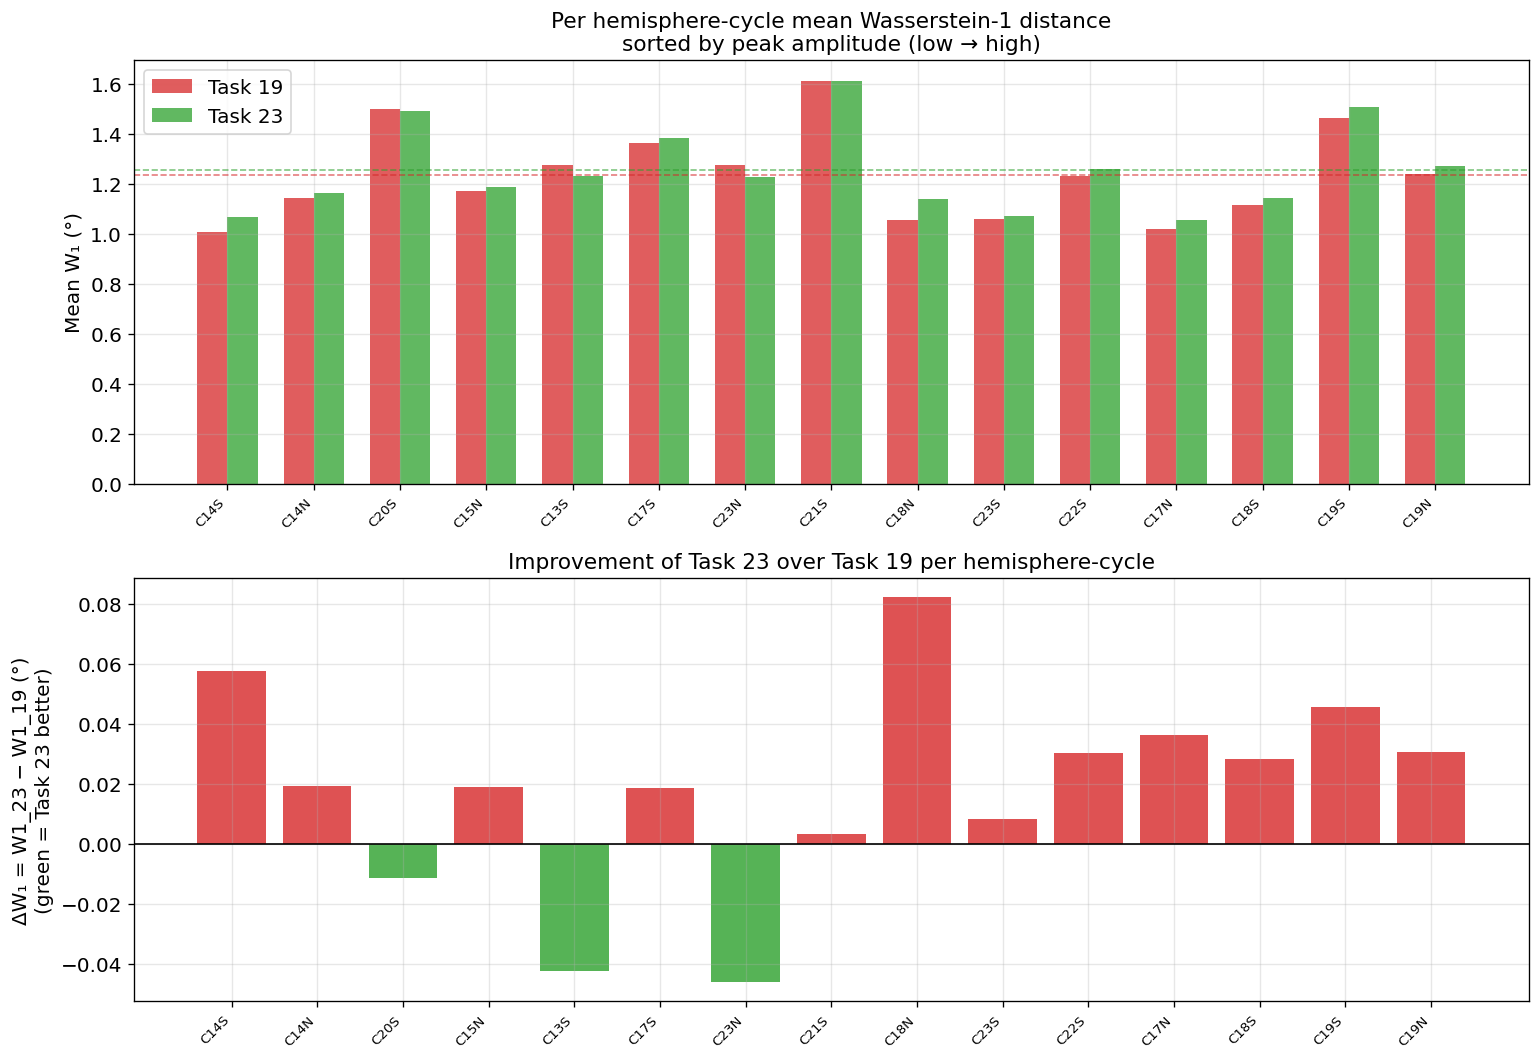

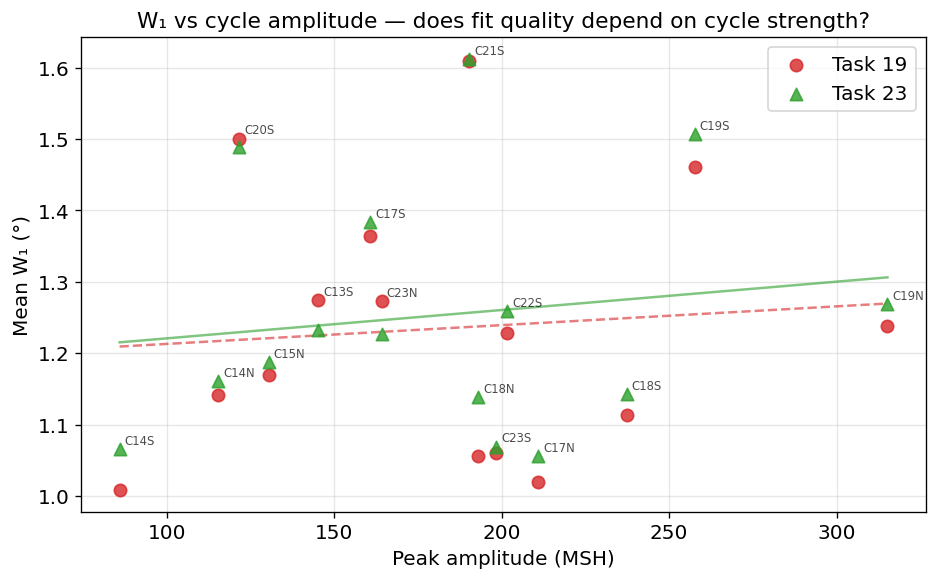


Outliers (W1_19 > mean + 1σ = 1.4176°):
  C20 south  A=122 MSH  W1_19=1.5004°  W1_23=1.4893°
  C21 south  A=190 MSH  W1_19=1.6089°  W1_23=1.6124°
  C19 south  A=258 MSH  W1_19=1.4613°  W1_23=1.5070°


In [27]:
from scipy.stats import wasserstein_distance

N_SAMPLES_24 = 10_000
rng_24       = np.random.default_rng(42)

records_24 = []

for (A, years_data), rec in zip(cycle_data_global, df19_records_global):
    cyc  = rec["cycle"]
    hemi = rec["hemisphere"]

    w1_19_list, w1_23_list = [], []

    for tau, mu, lats in years_data:
        mu0_19    = linear_fit(A, *fit_results_19["mu0"])
        mupeak_19 = linear_fit(A, *fit_results_19["mu_peak"])
        mi_19     = linear_fit(A, *fit_results_19["m_i"])

        if mu <= mu0_19:
            sigma_19 = piecewise_linear_wing(
                mu, m_shared_fit, b_shared_fit, mupeak_19, mi_19)
            if sigma_19 > 0:
                syn_19 = rng_24.normal(loc=mu, scale=sigma_19, size=N_SAMPLES_24)
                w1_19_list.append(wasserstein_distance(lats, syn_19))

        mu0_23    = linear_fit(A, *fit_results_23["mu0"])
        mupeak_23 = linear_fit(A, *fit_results_23["mu_peak"])
        mi_23     = linear_fit(A, *fit_results_23["m_i"])

        if mu <= mu0_23:
            sigma_23 = piecewise_linear_wing(
                mu, m_shared_fit, b_shared_fit, mupeak_23, mi_23)
            if sigma_23 > 0:
                syn_23 = rng_24.normal(loc=mu, scale=sigma_23, size=N_SAMPLES_24)
                w1_23_list.append(wasserstein_distance(lats, syn_23))

    if not w1_19_list and not w1_23_list:
        continue

    records_24.append(dict(
        cycle     = cyc,
        hemisphere= hemi,
        amplitude = A,
        w1_19     = np.mean(w1_19_list) if w1_19_list else np.nan,
        w1_23     = np.mean(w1_23_list) if w1_23_list else np.nan,
        n_years   = len(years_data)))

df24 = pd.DataFrame(records_24).sort_values("amplitude").reset_index(drop=True)

print(f"{'cyc':>4}  {'hemi':>5}  {'A (MSH)':>8}  {'W1_19 (°)':>10}  "
      f"{'W1_23 (°)':>10}  {'ΔW1 (°)':>10}  {'better':>8}")
for _, row in df24.iterrows():
    delta = row["w1_23"] - row["w1_19"]
    flag  = "Task23" if delta < 0 else "Task19"
    print(f"  {int(row.cycle):>3}  {row.hemisphere:>5}  {row.amplitude:>8.1f}  "
          f"{row.w1_19:>10.4f}  {row.w1_23:>10.4f}  {delta:>+10.4f}  {flag:>8}")

print(f"\nMean W1 — Task 19 : {df24['w1_19'].mean():.4f}°")
print(f"Mean W1 — Task 23 : {df24['w1_23'].mean():.4f}°")
print(f"Overall ΔW1       : {(df24['w1_23'] - df24['w1_19']).mean():+.4f}°")

# ──  Plot 1: W1 per cycle, both fits ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

x = np.arange(len(df24))
labels = [f"C{int(r.cycle)}{r.hemisphere[0].upper()}" for _, r in df24.iterrows()]
width  = 0.35

axes[0].bar(x - width/2, df24["w1_19"], width, label="Task 19",
            color="tab:red", alpha=0.75)
axes[0].bar(x + width/2, df24["w1_23"], width, label="Task 23",
            color="tab:green", alpha=0.75)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Mean W₁ (°)")
axes[0].set_title("Per hemisphere-cycle mean Wasserstein-1 distance\n"
                  "sorted by peak amplitude (low → high)")
axes[0].legend()
axes[0].axhline(df24["w1_19"].mean(), color="tab:red",
                linestyle="--", linewidth=1, alpha=0.6)
axes[0].axhline(df24["w1_23"].mean(), color="tab:green",
                linestyle="--", linewidth=1, alpha=0.6)
axes[0].grid(True, alpha=0.3, axis="y")

# ── Plot 2: ΔW1 vs amplitude ──────────────────────────────────────────────────
delta_w1 = df24["w1_23"] - df24["w1_19"]
colors = ["tab:green" if d < 0 else "tab:red" for d in delta_w1]
axes[1].bar(x, delta_w1, color=colors, alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("ΔW₁ = W1_23 − W1_19 (°)\n(green = Task 23 better)")
axes[1].set_title("Improvement of Task 23 over Task 19 per hemisphere-cycle")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Plot 3: W1 vs amplitude scatter ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df24["amplitude"], df24["w1_19"], color="tab:red",
           s=55, alpha=0.8, label="Task 19", zorder=3)
ax.scatter(df24["amplitude"], df24["w1_23"], color="tab:green",
           s=55, alpha=0.8, marker="^", label="Task 23", zorder=3)
for _, row in df24.iterrows():
    ax.annotate(f"C{int(row.cycle)}{row.hemisphere[0].upper()}",
                (row.amplitude, max(row.w1_19, row.w1_23)),
                textcoords="offset points", xytext=(3, 3), fontsize=7, alpha=0.7)
# Trend lines
for vals, color, ls in [(df24["w1_19"], "tab:red", "--"),
                         (df24["w1_23"], "tab:green", "-")]:
    m, b = np.polyfit(df24["amplitude"], vals, 1)
    ag   = np.linspace(df24["amplitude"].min(), df24["amplitude"].max(), 200)
    ax.plot(ag, m * ag + b, color=color, linewidth=1.5,
            linestyle=ls, alpha=0.6)

ax.set_xlabel("Peak amplitude (MSH)")
ax.set_ylabel("Mean W₁ (°)")
ax.set_title("W₁ vs cycle amplitude — does fit quality depend on cycle strength?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

threshold = df24["w1_19"].mean() + df24["w1_19"].std()
outliers  = df24[df24["w1_19"] > threshold]
print(f"\nOutliers (W1_19 > mean + 1σ = {threshold:.4f}°):")
for _, row in outliers.iterrows():
    print(f"  C{int(row.cycle)} {row.hemisphere:5s}  A={row.amplitude:.0f} MSH  "
          f"W1_19={row.w1_19:.4f}°  W1_23={row.w1_23:.4f}°")

Task 23 is worse than Task 19 on W1 for 12 out of 15 hemisphere-cycles, and the mean W1 increased by 0.019°. This seems contradictory since Task 23 improved NLL.

NLL and W1 are measuring different things. Task 23 optimized NLL, which is sensitive to the width (σ) of the Gaussian relative to the data spread. It found coefficients that produce better-calibrated widths globally. But W1 measures bulk location error, which is how far the predicted centre of mass is from the observed one. The Task 23 μ₀ intercept shift (21.0° → 24.3°) excludes more early-cycle years, which were the years where the predicted mean was closest to observed. Removing them improves NLL (those early years are hard to fit in shape) but the remaining years may have slightly worse location alignment.

The three outliers:
* C21 south (W1 = 1.61°) is the worst under both fits and neither improves it. Cycle 21 south is a well-documented case of extreme hemispheric asymmetry as the southern hemisphere peaked nearly 2.5 years after the north. A single-amplitude Gaussian cannot capture this.
*C20 south (W1 = 1.50°) and C19 south (W1 = 1.46°) are both southern hemisphere cycles where Task 23 marginally helps. These are strong cycles with large N-S timing offsets- the same asymmetry issue.
*The W1 vs amplitude scatter shows no clear trend (trend lines nearly flat), meaning the fit quality does not worsten at high or low amplitudes. The failures are cycle-specific, not amplitude-region failures, pointing to physical reasons (N-S asymmetry, cycle overlap) rather than a breakdown of the linear model.

---
## Task 25 — From Model to Samples: Generating a Synthetic Butterfly Diagram

The parametric model gives you a (μ_t, σ_t) pair for each year of a cycle — a complete statistical description of the latitude distribution in that year. But a butterfly *diagram* is a scatter of individual sunspot group positions. To turn the model into a diagram you need to **sample**.

Two choices govern the result:

1. **How many sunspots appear each year?** Use the annual mean of the 12-month smoothed total area from Task 17 as a proxy for activity level. Years with high area get more synthetic sunspots; quiet years get fewer. Set `N_SYNTHETIC = len(df_cyc_hemi)` to match the observed count for a fair visual comparison, or use a round number like 1 000 for a cleaner diagram.

2. **Where do the sunspots emerge?** Draw each latitude directly from the synthetic Gaussian N(±μ_t, σ_t) for that year, with no post-processing. The model speaks for itself — if the Gaussians are well calibrated, samples will naturally concentrate in the expected emergence zone; if not, the diagram will show you exactly where the model is wrong.

**This is a complete forward pass through the generative model:**  
amplitude → shape parameters → annual (μ_t, σ_t) → activity weights → sampled positions.  
In later weeks you will train a score-based diffusion model to learn this same mapping from data alone, without the analytical formulae.

Cycle 19 (north)  |  observed groups: 1585  |  synthetic target: 1585
A = 315.2 MSH  |  μ₀ = 30.47°  |  μ_peak = 19.56°  |  m_i = -0.3560

Year-by-year allocation:
 year       τ       μ       σ    weight   n_syn
  1955   -3.72   25.31°   6.467°      58.1      69
  1956   -2.72   22.50°   7.468°     173.1     205
  1957   -1.72   20.00°   8.357°     221.2     261
  1958   -0.72   17.78°   7.725°     255.9     302
  1959    0.28   15.80°   6.850°     281.4     333
  1960    1.28   14.05°   6.073°     161.7     191
  1961    2.28   12.49°   5.382°      81.6      96
  1962    3.28   11.10°   4.767°      43.7      52
  1963    4.28    9.87°   4.221°      32.6      38
  1964    5.28    8.77°   3.735°      11.0      13
  1965    6.28    7.80°   3.304°      21.2      25

Total Synthetic Sunspot Groups Generated: 1585


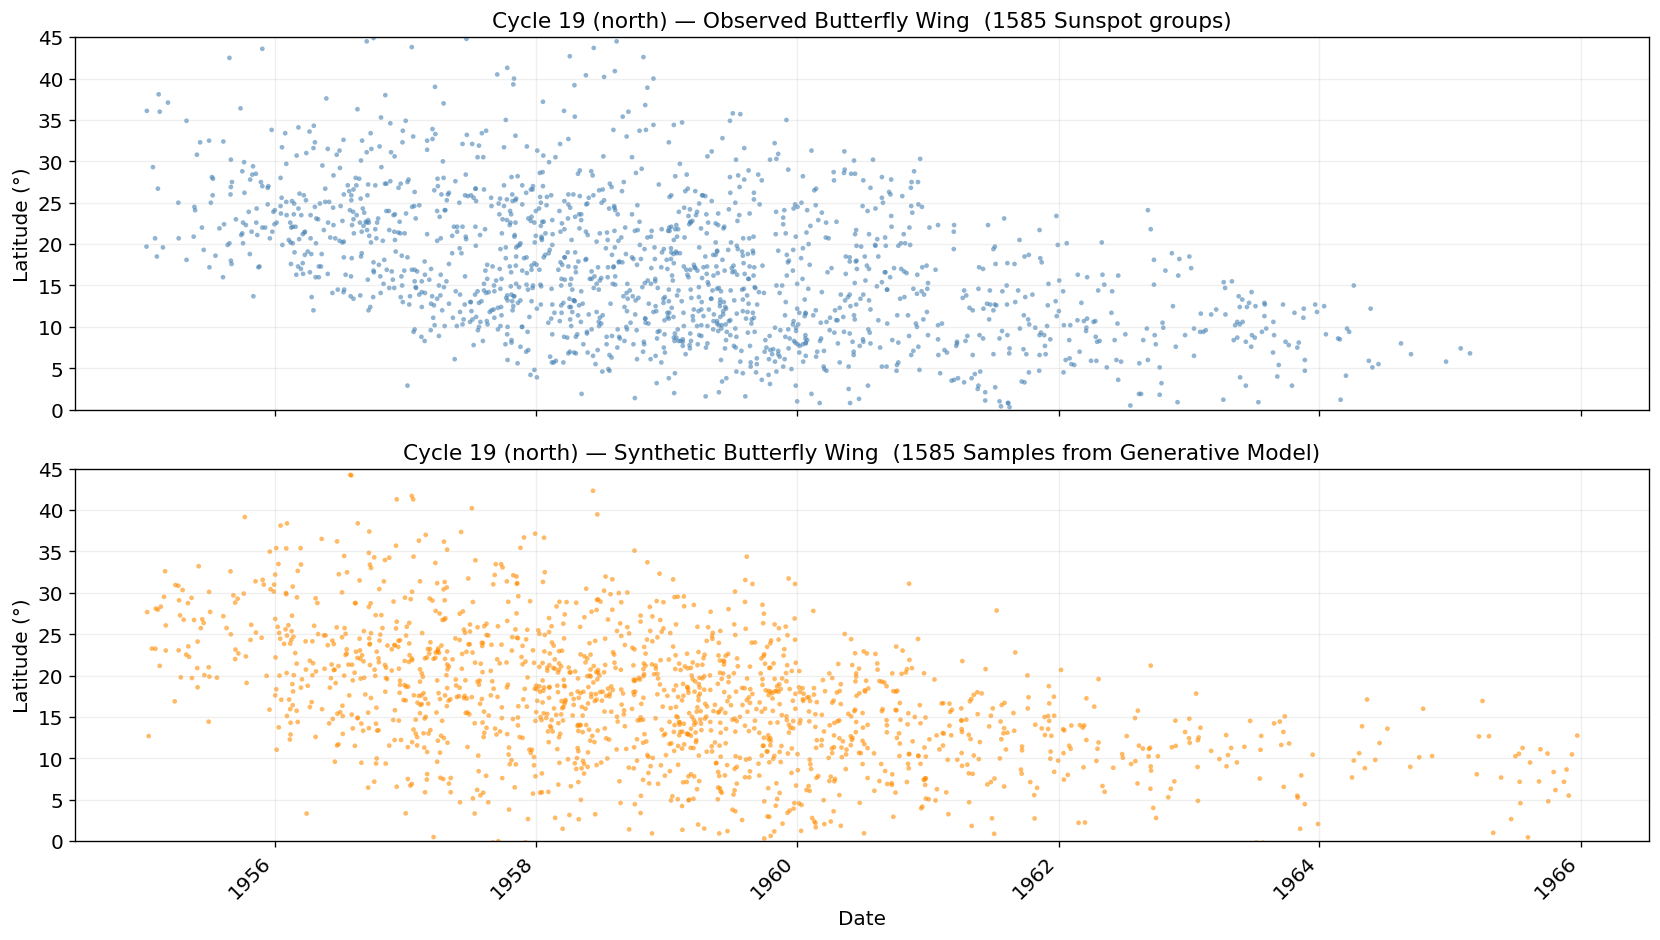

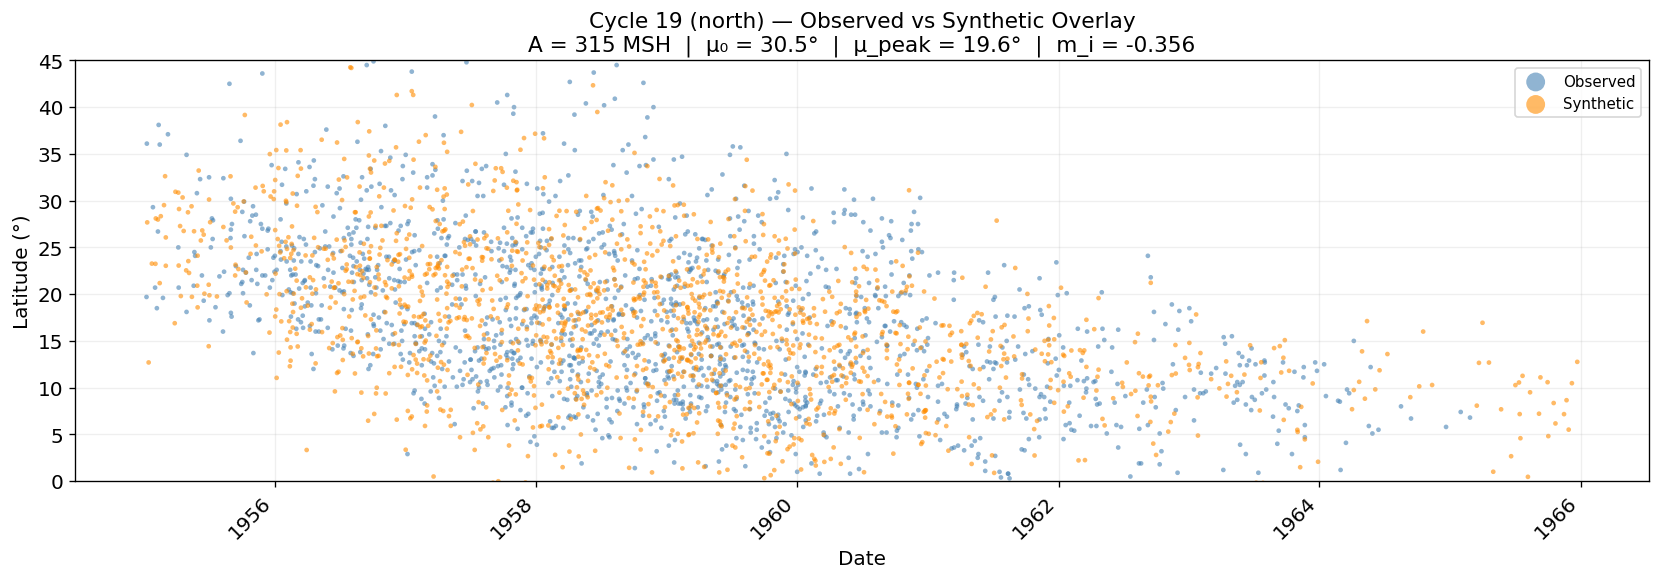

In [31]:
# Put your code here for Task 25.
# ── Task 25: Generating a Synthetic Butterfly Diagram ────────────────────────

from scipy.stats import norm as sp_norm

TARGET_CYCLE = 19
TARGET_HEMI  = "north"
N_SYNTHETIC  = None   # None = match observed count; set to int for fixed count

sign = +1 if TARGET_HEMI == "north" else -1

mask_25     = (df["CYCLE"] == TARGET_CYCLE) & (df["hemisphere"] == TARGET_HEMI)
df_cyc_25   = df[mask_25].copy()
years_25    = sorted(df_cyc_25["year"].unique())
n_observed  = len(df_cyc_25)

N_SYNTHETIC = n_observed if N_SYNTHETIC is None else N_SYNTHETIC
print(f"Cycle {TARGET_CYCLE} ({TARGET_HEMI})  |  observed groups: {n_observed}  "
      f"|  synthetic target: {N_SYNTHETIC}")

A_25        = amp_lookup[(TARGET_CYCLE, TARGET_HEMI)]
mu0_25      = linear_fit(A_25, *fit_results_23["mu0"])
mupeak_25   = linear_fit(A_25, *fit_results_23["mu_peak"])
mi_25       = linear_fit(A_25, *fit_results_23["m_i"])
t0_ref_25   = t0_refined[(TARGET_CYCLE, TARGET_HEMI)]

print(f"A = {A_25:.1f} MSH  |  μ₀ = {mu0_25:.2f}°  "
      f"|  μ_peak = {mupeak_25:.2f}°  |  m_i = {mi_25:.4f}")

smooth_hemi = smooth_north if TARGET_HEMI == "north" else smooth_south

year_params = []
for yr in years_25:
    tau = (yr + 0.5) - t0_ref_25
    mu  = exp_decay(tau, a_mu_univ, b_mu_univ)

    if mu > mu0_25:
        continue

    sigma = piecewise_linear_wing(
        mu, m_shared_fit, b_shared_fit, mupeak_25, mi_25)
    if sigma <= 0:
        continue

    # Annual mean of 12-month smoothed area as activity weight
    yr_smooth = smooth_hemi[
        (smooth_hemi.index.year == yr)].mean()
    if np.isnan(yr_smooth):
        yr_smooth = 0.0

    year_params.append(dict(
        year=yr, tau=tau, mu=mu, sigma=sigma, weight=yr_smooth))

df_yp = pd.DataFrame(year_params)

total_weight       = df_yp["weight"].sum()
df_yp["n_samples"] = (df_yp["weight"] / total_weight * N_SYNTHETIC).round().astype(int)

deficit = N_SYNTHETIC - df_yp["n_samples"].sum()
if deficit != 0:
    idx = df_yp["n_samples"].idxmax()
    df_yp.loc[idx, "n_samples"] += deficit

print(f"\nYear-by-year allocation:")
print(f"{'year':>5}  {'τ':>6}  {'μ':>6}  {'σ':>6}  "
      f"{'weight':>8}  {'n_syn':>6}")
for _, row in df_yp.iterrows():
    print(f"  {int(row.year):>4}  {row.tau:>6.2f}  {row.mu:>6.2f}°  "
          f"{row.sigma:>6.3f}°  {row.weight:>8.1f}  {int(row.n_samples):>6}")

rng_25 = np.random.default_rng(42)
syn_records = []

for _, row in df_yp.iterrows():
    n   = int(row["n_samples"])
    if n <= 0:
        continue
    lats = rng_25.normal(loc=sign * row["mu"], scale=row["sigma"], size=n)
    # Anchor at a random day within the year for plotting
    days_offset = rng_25.integers(0, 365, size=n)
    dates = [pd.Timestamp(f"{int(row.year)}-01-01") +
             pd.Timedelta(days=int(d)) for d in days_offset]
    for lat, date in zip(lats, dates):
        syn_records.append({"date": date, "latitude": lat, "year": int(row.year)})

df_syn = pd.DataFrame(syn_records)
print(f"\nTotal Synthetic Sunspot Groups Generated: {len(df_syn)}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Observed
axes[0].scatter(df_cyc_25["date"], df_cyc_25["latitude"],
                s=8, color="steelblue", alpha=0.6, edgecolors="none")
axes[0].set_ylabel("Latitude (°)")
axes[0].set_title(f"Cycle {TARGET_CYCLE} ({TARGET_HEMI}) — Observed Butterfly Wing  "
                  f"({n_observed} Sunspot groups)")
axes[0].set_ylim(-5 if TARGET_HEMI == "south" else 0,
                  45 if TARGET_HEMI == "north" else 5)
axes[0].axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.4)
axes[0].grid(True, alpha=0.2)

# Synthetic
axes[1].scatter(df_syn["date"], df_syn["latitude"],
                s=8, color="darkorange", alpha=0.6, edgecolors="none")
axes[1].set_ylabel("Latitude (°)")
axes[1].set_title(f"Cycle {TARGET_CYCLE} ({TARGET_HEMI}) — Synthetic Butterfly Wing  "
                  f"({N_SYNTHETIC} Samples from Generative Model)")
axes[1].set_ylim(-5 if TARGET_HEMI == "south" else 0,
                  45 if TARGET_HEMI == "north" else 5)
axes[1].axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.4)
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.2)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.scatter(df_cyc_25["date"], df_cyc_25["latitude"],
            s=8, color="steelblue", alpha=0.6,
            edgecolors="none", label="Observed")
ax2.scatter(df_syn["date"], df_syn["latitude"],
            s=8, color="darkorange", alpha=0.6,
            edgecolors="none", label="Synthetic")
ax2.set_ylim(0 if TARGET_HEMI == "north" else -45,
             45 if TARGET_HEMI == "north" else 0)
ax2.set_ylabel("Latitude (°)")
ax2.set_xlabel("Date")
ax2.set_title(f"Cycle {TARGET_CYCLE} ({TARGET_HEMI}) — Observed vs Synthetic Overlay\n"
              f"A = {A_25:.0f} MSH  |  μ₀ = {mu0_25:.1f}°  "
              f"|  μ_peak = {mupeak_25:.1f}°  |  m_i = {mi_25:.3f}")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.legend(markerscale=4, fontsize=9)
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Going Further — Ideas for a Model Quality Scoreboard

Everything built in this notebook rests on six numbers: the slopes and intercepts of the three linear amplitude–shape relationships. These six numbers determine your score on `compute_global_nll`. The challenge: **how low can you drive it?**

Below is a menu of modifications ordered roughly by difficulty. Each one is a testable hypothesis about the physics or statistics of solar cycles — the NLL gives you an objective way to know if the hypothesis is right. Keep a record of your best score and the approach that achieved it; at the end of the program we will compare across the group.

---

### Level 1 — Tune the inputs (no new code structures needed)

1. **Cycle selection:** The default uses all cycles ≥ 12. Try restricting to ≥ 14, which excludes the most heterogeneous early data. Does quality gain outweigh losing two training cycles?

2. **Amplitude proxy:** You used the 12-month rolling-average peak. Try a different window (6 months, 24 months), or the cycle-integrated total area instead of the peak. Does a different amplitude definition give better-predicted relationships?

3. **Better initialization:** Nelder-Mead is sensitive to starting points. Add random noise (±20%) to `x0_23` and run the optimizer several times; keep the best. Does the Task 19 initialization reliably find the global minimum?

---

### Level 2 — Change the functional form (more parameters, new optimizer runs)

4. **Non-linear amplitude relationships:** Replace one or more linear fits with a power law ($a \cdot A^b$) or quadratic. If the scatter in Task 19 looks curved, a non-linear form may lower the NLL.

5. **Optimize the shared equatorial line:** Pass `m_sh` and `b_sh` to `compute_global_nll` and include them in the parameter vector (8 parameters total). Is the universal equatorial line truly universal, or does it drift with amplitude?

6. **Soft μ₀ threshold:** Replace the hard cutoff with a sigmoid weight  
   `w = 1 / (1 + exp((μ − μ₀) / T))`, temperature T ≈ 1°.  
   This makes the objective differentiable → switch from Nelder-Mead to L-BFGS-B.

---

### Level 3 — Change the model structure (substantive physics changes)

7. **Optimize the universal path:** Currently `a_mu_univ` and `b_mu_univ` are fixed. Add them as free parameters (10 total). Does the shape of the equatorward drift depend on activity level?

8. **Asymmetric spread:** The per-year Gaussian uses the same σ on both sides of μ. Replace it with a split-Gaussian (separate poleward and equatorward widths) — add `m_i_R` as a fourth amplitude relationship.

9. **Heavy-tailed distribution:** Replace the Gaussian with a Student-t (parameter ν). Very active years have occasional high-latitude sunspots that a Gaussian penalizes heavily — a heavier tail may help.


---

### Level 4 — Reframe the definition of the dependence of the with width as something directly connected to cycle amplitude (as in task 17)

1. SARGE (our state-of-the-art benchmark) defines the width of the wing through a direct relationship between wing width and cycle amplitude (see item 2, section 3. SARG in https://arxiv.org/abs/2511.19371; page 4).  What happens if you reframe things that way?  Make sure you define it using the hemispheric total area, not the whole-sun total area like SARGE.

2. SARGE doesn't include a different treatment of wing expansion vs. collapse, can you find a way of doing that?

---

### Level 5 — Advanced experiments

10. **Cross-validation:** Fit on cycles 12–19, evaluate on 20–25. A large gap between training and held-out NLL signals overfitting — simpler functional forms may generalize better.

11. **Era weighting:** Down-weight pre-1976 RGO cycles by 0.5 in the NLL sum. Does this improve fit on the modern, well-calibrated USAF cycles?

12. **Hemisphere-specific fits:** Fit north and south independently. Does the north–south asymmetry documented in the literature show up in different regression slopes?

In [32]:
# ── Model Quality Scoreboard ──────────────────────────────────────────────
# Replace fit_results_best with whatever set of coefficients you want to evaluate.
# fit_results_23 is the end-to-end optimized result from Task 23.

fit_results_best = fit_results_23   # ← swap in your best result here.  This cell will likely need adjustment

nll_baseline = compute_global_nll(fit_results_19)
nll_best     = compute_global_nll(fit_results_best)
pct_gain     = (nll_baseline - nll_best) / abs(nll_baseline) * 100

print("=" * 56)
print("  Model Quality Scoreboard")
print("=" * 56)
print(f"  Baseline (Task 19 two-stage) : {nll_baseline:.5f} nats/year")
print(f"  Your best model              : {nll_best:.5f} nats/year")
print(f"  Improvement (Δ NLL)          : {nll_best - nll_baseline:+.5f} nats/year"
      f"  ({pct_gain:.2f}%)")
print("=" * 56)

# ── Template: evaluate any custom coefficient set ─────────────────────────
# Uncomment and fill in your own values to try a different model:
#
# my_fit = {
#     "mu0":    (slope, intercept),   # mu0(A)    = slope * A + intercept
#     "mu_peak":(slope, intercept),   # mu_peak(A) = ...
#     "m_i":    (slope, intercept),   # m_i(A)    = ...
# }
# print(f"Custom model : {compute_global_nll(my_fit):.5f} nats/year")
#
# To also optimize the shared equatorial line (Section 5 parameters):
# print(f"Custom model : {compute_global_nll(my_fit, m_sh=0.12, b_sh=-0.5):.5f}")

  Model Quality Scoreboard
  Baseline (Task 19 two-stage) : 3.09328 nats/year
  Your best model              : 3.08731 nats/year
  Improvement (Δ NLL)          : -0.00596 nats/year  (0.19%)
